In [189]:
import numpy as np
import matplotlib.pyplot as plt
import math
import cmath
# import matplotlib.colors as colors
# import matplotlib.axes as ax
# import csv
# import pandas as pd
# import re
# from mpl_toolkits.axes_grid1 import make_axes_locatable
# from matplotlib.colors import colorConverter
# import matplotlib.gridspec as gridspec
# from matplotlib.figure import Figure 
# from mpl_toolkits.axisartist.axislines import Subplot  


<span style="font-size: 48px;">Dependence of dielectric constant on φ₁</span>

In [12]:
H_max = 5000
coeff = 160
h = np.linspace(0, H_max, H_max*coeff+1)
eps_0 = [0]*(H_max*coeff+1)
eps_w_real = [0]*(H_max*coeff+1)
eps_kj_real =[0]*(H_max*coeff+1)
eps_l_real = [0]*(H_max*coeff+1)
eps_w_complex = [0]*(H_max*coeff+1)
eps_kj_complex =[0]*(H_max*coeff+1)
eps_l_complex = [0]*(H_max*coeff+1)
phi_1_arr = [0]*(H_max*coeff+1)

In [13]:
eps_1= 4.560 + cmath.sqrt(-1)*0.251
b=0.28
rho=2440.0

#visibility
V_arr = np.linspace(0.1,15,H_max*coeff+1) ; #meters
h_0 = 2.0

#for Libya and Sudan
gamma = 1.07
C = 2.3*1.e-2
for i in range(H_max*coeff+1):
    phi_1_arr[i] = C/(rho*pow(V_arr[i],gamma))

In [14]:
eps_0 = [0]*(H_max*coeff+1)
for i in range(H_max*coeff+1):
    eps_0[i] =  pow ((1 + (315*math.exp(-1.36 *1.e-4*h[i]))*1.e-6),2)

In [15]:
for i in range(H_max*coeff+1):
    eps_w_real[i]  = 3*eps_0[i]*phi_1_arr[i]*(eps_1-eps_0[i])/(eps_1+2*eps_0[i]) + eps_0[i]
    eps_w_real[i] = eps_w_real[i].real

In [16]:
for i in range(H_max*coeff+1):
    eps_kj_real[i] = (2*eps_0[i]*phi_1_arr[i]*(eps_1-eps_0[i]) + eps_0[i]*eps_1 + 2*eps_0[i]*eps_0[i])/(eps_1+2*eps_0[i]-phi_1_arr[i]*(eps_1-eps_0[i]))
    eps_kj_real[i] = eps_kj_real[i].real

In [17]:
for i in range(H_max*coeff+1):
    eps_l_real[i] = pow((phi_1_arr[i]*(pow(eps_1,1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3)
    eps_l_real[i] = eps_l_real[i].real

In [18]:
for i in range(H_max*coeff+1):
    eps_w_complex[i]  = 3.0*eps_0[i]*phi_1_arr[i]*(eps_1-eps_0[i])/(eps_1+2.0*eps_0[i]) + eps_0[i]
    eps_w_complex[i]  = eps_w_complex[i].imag

In [19]:
for i in range(H_max*coeff+1):
    eps_kj_complex[i] = (2.0*eps_0[i]*phi_1_arr[i]*(eps_1-eps_0[i]) + eps_0[i]*eps_1 + 2*eps_0[i]*eps_0[i])/(eps_1+2*eps_0[i]-phi_1_arr[i]*(eps_1-eps_0[i]))
    eps_kj_complex[i] = eps_kj_complex[i].imag

In [20]:
for i in range(H_max*coeff+1):
    eps_l_complex[i] = pow((phi_1_arr[i]*(pow(eps_1,1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3)
    eps_l_complex[i] = eps_l_complex[i].imag

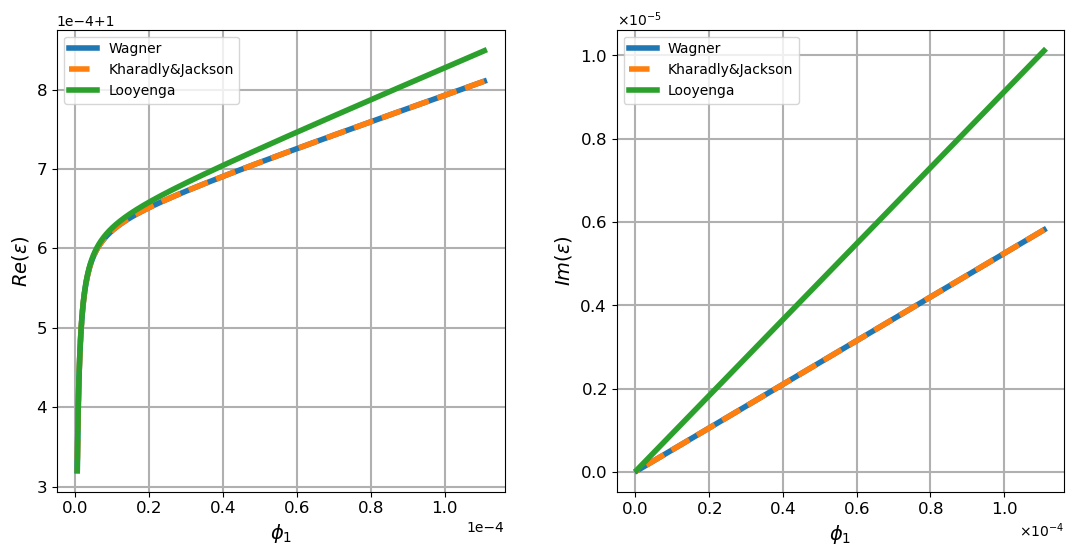

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Ваш существующий код здесь

fig, axs = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'wspace': 0.25})

# Построение графиков
axs[0].plot(phi_1_arr, eps_w_real, label='Wagner', linewidth=4)
axs[0].plot(phi_1_arr, eps_kj_real, label='Kharadly&Jackson', linewidth=4, linestyle='--')
axs[0].plot(phi_1_arr, eps_l_real, label='Looyenga', linewidth=4)
axs[0].set_ylabel('$Re(ε)$', fontsize=14)
axs[0].set_xlabel('$\phi_1$', fontsize=14) 
axs[0].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[0].ticklabel_format(style='sci', axis='Both', scilimits=(0,0))  # Представление значений на оси x в экспоненциальной форме
axs[0].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[0].legend()

axs[1].plot(phi_1_arr, eps_w_complex, label='Wagner', linewidth=4)
axs[1].plot(phi_1_arr, eps_kj_complex, label='Kharadly&Jackson', linewidth=4, linestyle='--')
axs[1].plot(phi_1_arr, eps_l_complex, label='Looyenga', linewidth=4)
axs[1].set_xlabel('$\phi_1$', fontsize=14)
axs[1].set_ylabel('$Im(ε)$', fontsize=14)
axs[1].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[1].ticklabel_format(style='sci', axis='Both', scilimits=(0,0),  useMathText=True, useOffset=False)  # Представление значений на оси x в экспоненциальной форме
axs[1].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[1].legend()

plt.show()

In [292]:
cols = 2
Humidity = np.linspace(0,1,cols)
eps_1 = [0]*(cols)
for i in range(cols):
    eps_1[i]= (4.56 + 0.04*Humidity[i] - 7.78*pow(Humidity[i],2)*1.e-4 + 5.56*pow(Humidity[i],3)*1.e-6) + cmath.sqrt(-1)*(0.251+ 0.02*Humidity[i] - 3.71*pow(Humidity[i],2)*1.e-4 + 2.76*pow(Humidity[i],3)*1.e-6)

In [293]:
b=0.28
rho=2440.0

#visibility
V_arr = np.linspace(0.1,15,H_max*coeff+1) ; #meters
h_0 = 2.0

#for Libya and Sudan
gamma = 1.07
C = 2.3*1.e-2
for i in range(H_max*coeff+1):
    phi_1_arr[i] = C/(rho*pow(V_arr[i],gamma))

In [294]:
eps_w_real = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_kj_real = np.zeros((H_max*coeff+1,cols),dtype=complex) 
eps_l_real = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_w_complex = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_kj_complex = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_l_complex = np.zeros((H_max*coeff+1,cols),dtype=complex)

In [295]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_w_real[i][j] = 3 * eps_0[i] * phi_1_arr[i] * (eps_1[j] - eps_0[i]) / (eps_1[j] + 2 * eps_0[i]) + eps_0[i]
eps_w_real = np.real(eps_w_real)


In [296]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_kj_real[i][j] =(2*eps_0[i]*phi_1_arr[i]*(eps_1[j]-eps_0[i]) + eps_0[i]*eps_1[j] + 2*eps_0[i]*eps_0[i])/(eps_1[j]+2*eps_0[i]-phi_1_arr[i]*(eps_1[j]-eps_0[i]))
eps_kj_real = np.real(eps_kj_real)

In [297]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_l_real[i][j] = pow((phi_1_arr[i]*(pow(eps_1[j],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3)
eps_l_real = np.real(eps_l_real)

In [298]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_w_complex[i][j] = (3*eps_0[i]*phi_1_arr[i]*(eps_1[j] - eps_0[i])/(eps_1[j] + 2*eps_0[i]) + eps_0[i])
eps_w_complex = np.imag(eps_w_complex)

In [299]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_kj_complex[i][j] = (2*eps_0[i]*phi_1_arr[i]*(eps_1[j]-eps_0[i]) + eps_0[i]*eps_1[j] + 2*eps_0[i]*eps_0[i])/(eps_1[j]+2*eps_0[i]-phi_1_arr[i]*(eps_1[j]-eps_0[i]))
eps_kj_complex = np.imag(eps_kj_complex)

In [300]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_l_complex[i][j] = (pow((phi_1_arr[i]*(pow(eps_1[j],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3))
eps_l_complex= np.imag(eps_l_complex)

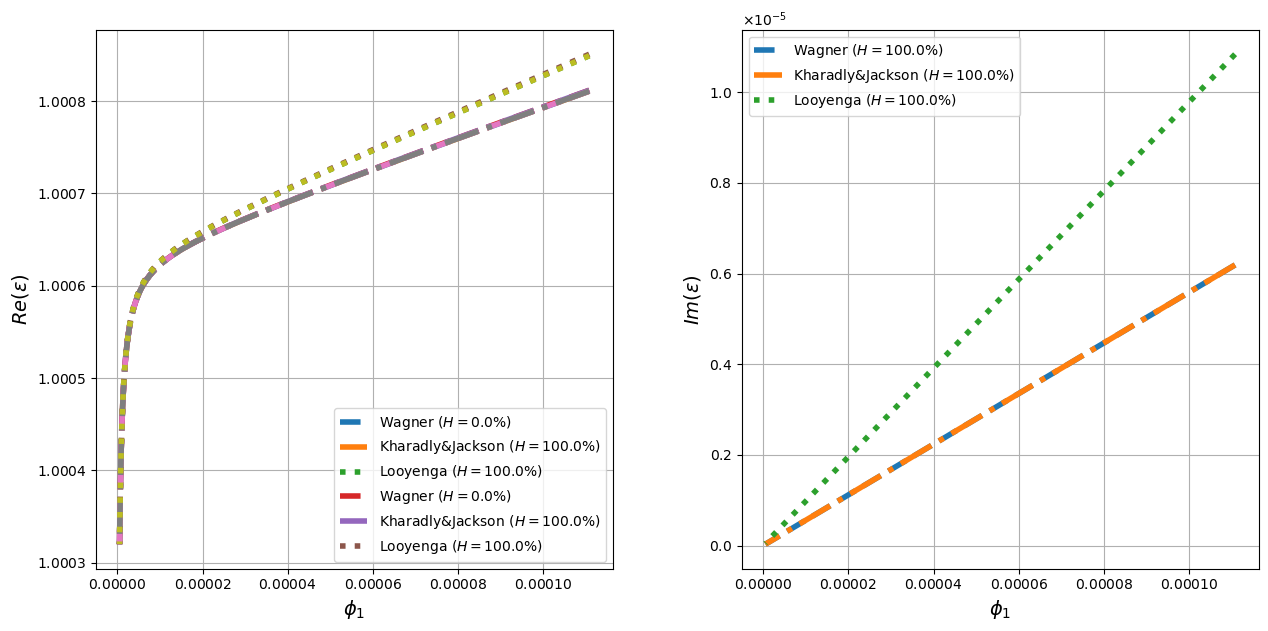

In [301]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'wspace': 0.25} )
#fig.suptitle('Добавление влажности ($H = {} \% $)'.format(Humidity*100))


axs[0].plot(phi_1_arr, eps_w_real[:,0],  label='Wagner ($H = {} \% $)'.format(Humidity[0]*100), linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr,eps_kj_real[:,0], label='Kharadly&Jackson ($H = {} \% $)'.format(Humidity[1]*100), linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr,eps_l_real[:,0],  label='Looyenga ($H = {} \% $)'.format(Humidity[1]*100), linewidth='4', linestyle=':')
axs[0].plot(phi_1_arr, eps_w_real[:,1],  label='Wagner ($H = {} \% $)'.format(Humidity[0]*100), linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr,eps_kj_real[:,1], label='Kharadly&Jackson ($H = {} \% $)'.format(Humidity[1]*100), linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr,eps_l_real[:,1],  label='Looyenga ($H = {} \% $)'.format(Humidity[1]*100), linewidth='4', linestyle=':')

axs[0].set_ylabel('$Re(ε)$', fontsize=14)
axs[0].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
#axs[0].set_title('Стандартная рефракция без пыли')
axs[0].ticklabel_format(style='scientific', axis='Both', useMathText=True, useOffset=False)
axs[0].grid(True)
axs[0].legend()


axs[0].plot(phi_1_arr, eps_w_real[:,0],  label='Wagner ($H = {} \% $)'.format(Humidity[0]*100), linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr,eps_kj_real[:,0], label='Kharadly&Jackson ($H = {} \% $)'.format(Humidity[0]*100), linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr,eps_l_real[:,0],  label='Looyenga ($H = {} \% $)'.format(Humidity[0]*100), linewidth='4', linestyle=':')
axs[1].plot(phi_1_arr,eps_w_complex[:,1],   label='Wagner ($H = {} \% $)'.format(Humidity[1]*100), linewidth='4', linestyle='--')
axs[1].plot(phi_1_arr,eps_kj_complex[:,1],  label='Kharadly&Jackson ($H = {} \% $)'.format(Humidity[1]*100), linewidth='4', linestyle='-.')
axs[1].plot(phi_1_arr,eps_l_complex[:,1], label='Looyenga ($H = {} \% $)'.format(Humidity[1]*100), linewidth='4', linestyle=':')

axs[1].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
axs[1].set_ylabel('$Im(ε)$', fontsize=14)
# axs[1].set_title()
axs[1].ticklabel_format(style='scientific', axis='Both', useMathText=True, useOffset=False)
axs[1].grid(True)
axs[1].legend()

plt.show()


<span style="font-size: 48px;">Calculations for various models with φ₁ = φ₁(V) </span>

In [51]:
eps_1= [4.560 + cmath.sqrt(-1)*0.251]*(H_max*coeff+1)

new_range = 2*coeff


eps_w_real = [0]*(H_max*coeff+1)
eps_kj_real =[0]*(H_max*coeff+1)
eps_l_real = [0]*(H_max*coeff+1)
eps_w_complex = [0]*(H_max*coeff+1)
eps_kj_complex =[0]*(H_max*coeff+1)
eps_l_complex = [0]*(H_max*coeff+1)
phi_1_arr = [0]*(H_max*coeff+1)

b=0.28
rho=2440.0

#visibility
V_arr = np.linspace(0.1,15,H_max*coeff+1) ; #meters
h_0 = 2.0

#for Libya and Sudan
gamma = 1.07
C = 2.3*1.e-2
for i in range(H_max*coeff+1):
    phi_1_arr[i] = C/(rho*pow(V_arr[i],gamma))

In [52]:
for i in range(H_max*coeff+1):
    eps_w_real[i]  = 3*eps_0[i]*phi_1_arr[i]*(eps_1[i]-eps_0[i])/(eps_1[i]+2*eps_0[i]) + eps_0[i]
    eps_w_real[i] = eps_w_real[i].real


In [53]:
for i in range(H_max*coeff+1):
    eps_kj_real[i] = (2*eps_0[i]*phi_1_arr[i]*(eps_1[i]-eps_0[i]) + eps_0[i]*eps_1[i] + 2*eps_0[i]*eps_0[i])/(eps_1[i]+2*eps_0[i]-phi_1_arr[i]*(eps_1[i]-eps_0[i]))
    eps_kj_real[i] = eps_kj_real[i].real

In [54]:
for i in range(H_max*coeff+1):
    eps_l_real[i] = pow((phi_1_arr[i]*(pow(eps_1[i],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3)
    eps_l_real[i] = eps_l_real[i].real

In [55]:
for i in range(H_max*coeff+1):
    eps_w_complex[i]  = 3*eps_0[i]*phi_1_arr[i]*(eps_1[i]-eps_0[i])/(eps_1[i]+2*eps_0[i]) + eps_0[i]
    eps_w_complex[i]  = eps_w_complex[i].imag

In [56]:
for i in range(H_max*coeff+1):
    eps_kj_complex[i] = (2*eps_0[i]*phi_1_arr[i]*(eps_1[i]-eps_0[i]) + eps_0[i]*eps_1[i] + 2*eps_0[i]*eps_0[i])/(eps_1[i]+2*eps_0[i]-phi_1_arr[i]*(eps_1[i]-eps_0[i]))
    eps_kj_complex[i] = eps_kj_complex[i].imag

In [57]:
for i in range(H_max*coeff+1):
    eps_l_complex[i] = pow((phi_1_arr[i]*(pow(eps_1[i],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3)
    eps_l_complex[i] = eps_l_complex[i].imag

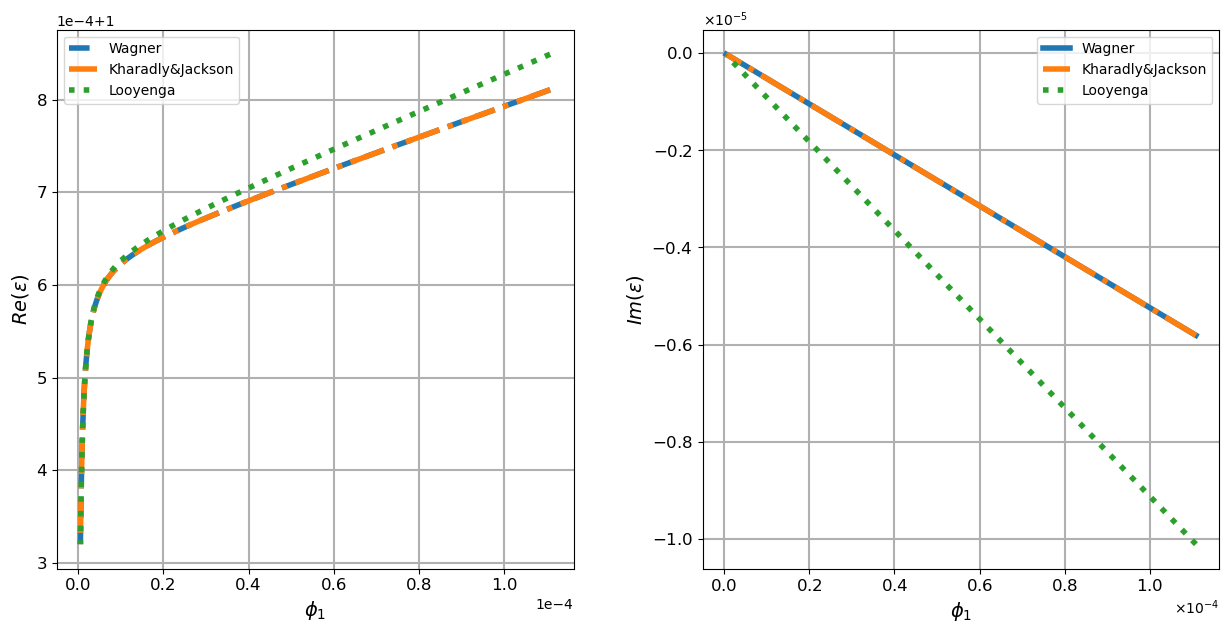

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'wspace': 0.25} )
#fig.suptitle('Добавление влажности ($H = {} \% $)'.format(Humidity*100))

# axs[0].plot(phi_1_arr, eps_0, label='$ε_0$', linewidth='4', linestyle='-')
axs[0].plot(phi_1_arr, eps_w_real, label='Wagner', linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr, eps_kj_real, label='Kharadly&Jackson', linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr, eps_l_real, label='Looyenga', linewidth='4', linestyle=':')
axs[0].set_ylabel('$Re(ε)$', fontsize=14)
axs[0].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
#axs[0].set_title('Стандартная рефракция без пыли')
axs[0].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[0].ticklabel_format(style='sci', axis='Both', scilimits=(0,0))  # Представление значений на оси x в экспоненциальной форме
axs[0].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[0].legend()

axs[1].plot(phi_1_arr, eps_w_complex, label='Wagner', linewidth='4', linestyle='-')
axs[1].plot(phi_1_arr, eps_kj_complex, label='Kharadly&Jackson', linewidth='4', linestyle='-.')
axs[1].plot(phi_1_arr, eps_l_complex, label='Looyenga', linewidth='4', linestyle=':')
axs[1].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
axs[1].set_ylabel('$Im(ε)$', fontsize=14)
# axs[1].set_title()
axs[1].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[1].ticklabel_format(style='sci', axis='Both', scilimits=(0,0),  useMathText=True, useOffset=False)  # Представление значений на оси x в экспоненциальной форме
axs[1].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[1].legend()

plt.show()




<span style="font-size: 48px;">Calculations for various models with φ₁ = φ₁(V) (adding dependence on humidity)</span>

In [ ]:
cols = 2
Humidity = np.linspace(0,1,cols)
eps_1 = [0]*(cols)
for i in range(cols):
    eps_1[i]= (4.56 + 0.04*Humidity[i] - 7.78*pow(Humidity[i],2)*1.e-4 + 5.56*pow(Humidity[i],3)*1.e-6) + cmath.sqrt(-1)*(0.251+ 0.02*Humidity[i] - 3.71*pow(Humidity[i],2)*1.e-4 + 2.76*pow(Humidity[i],3)*1.e-6)
    
b=0.28
rho=2440.0

#visibility
V_arr = np.linspace(0.1,15,H_max*coeff+1) ; #meters
h_0 = 2.0

#for Libya and Sudan
gamma = 1.07
C = 2.3*1.e-2
for i in range(H_max*coeff+1):
    phi_1_arr[i] = C/(rho*pow(V_arr[i],gamma))

In [79]:
b=0.28
rho=2440.0

#visibility
V_0 = 0.5; #meters
h_0 = 2.0

#for Libya and Sudan
gamma = 1.07
C = 2.3*1.e-2
new_range = 2*coeff

for i in range(H_max*coeff+1):
    if i<new_range :
        phi_1_arr[i] = C*pow(h_0/h_0,b)/(rho*pow(V_0,gamma))
    else:
        phi_1_arr[i] = C*pow(h_0/h[i],b)/(rho*pow(V_0,gamma))

In [80]:
eps_w_real = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_kj_real = np.zeros((H_max*coeff+1,cols),dtype=complex) 
eps_l_real = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_w_complex = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_kj_complex = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_l_complex = np.zeros((H_max*coeff+1,cols),dtype=complex)

In [81]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_w_real[i][j] = 3 * eps_0[i] * phi_1_arr[i] * (eps_1[j] - eps_0[i]) / (eps_1[j] + 2 * eps_0[i]) + eps_0[i]
eps_w_real = np.real(eps_w_real)


In [82]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_kj_real[i][j] =(2*eps_0[i]*phi_1_arr[i]*(eps_1[j]-eps_0[i]) + eps_0[i]*eps_1[j] + 2*eps_0[i]*eps_0[i])/(eps_1[j]+2*eps_0[i]-phi_1_arr[i]*(eps_1[j]-eps_0[i]))
eps_kj_real = np.real(eps_kj_real)

In [83]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_l_real[i][j] = pow((phi_1_arr[i]*(pow(eps_1[j],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3)
eps_l_real = np.real(eps_l_real)

In [84]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_w_complex[i][j] = (3*eps_0[i]*phi_1_arr[i]*(eps_1[j] - eps_0[i])/(eps_1[j] + 2*eps_0[i]) + eps_0[i])
eps_w_complex = np.imag(eps_w_complex)

In [85]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_kj_complex[i][j] = (2*eps_0[i]*phi_1_arr[i]*(eps_1[j]-eps_0[i]) + eps_0[i]*eps_1[j] + 2*eps_0[i]*eps_0[i])/(eps_1[j]+2*eps_0[i]-phi_1_arr[i]*(eps_1[j]-eps_0[i]))
eps_kj_complex = np.imag(eps_kj_complex)

In [86]:
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_l_complex[i][j] = (pow((phi_1_arr[i]*(pow(eps_1[j],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3))
eps_l_complex= np.imag(eps_l_complex)

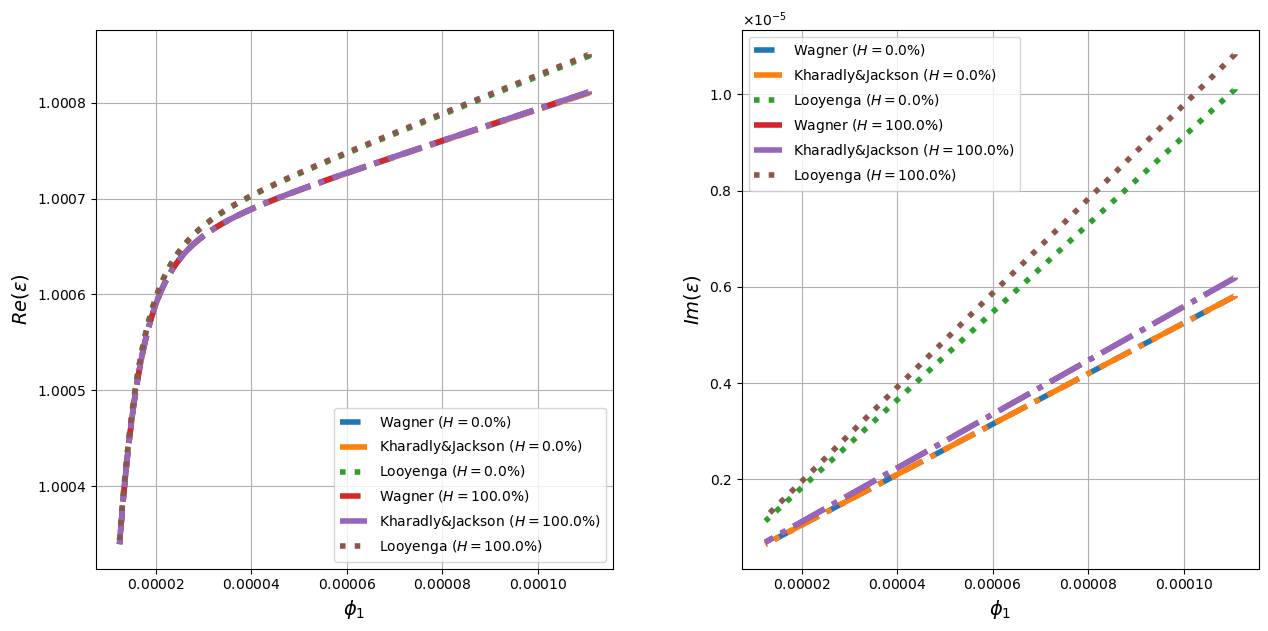

In [76]:
indx_begin = 0
indx_end = 1

fig, axs = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'wspace': 0.25} )
#fig.suptitle('Добавление влажности ($H = {} \% $)'.format(Humidity*100))


axs[0].plot(phi_1_arr, eps_w_real[:,indx_begin],   label='Wagner ($H = {} \% $)'.format(Humidity[indx_begin]*100), linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr, eps_kj_real[:,indx_begin], label='Kharadly&Jackson ($H = {} \% $)'.format(Humidity[indx_begin]*100), linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr,eps_l_real[:,indx_begin],  label='Looyenga ($H = {} \% $)'.format(Humidity[indx_begin]*100), linewidth='4', linestyle=':')
axs[0].plot(phi_1_arr,eps_w_real[:,indx_end],  label='Wagner ($H = {} \% $)'.format(Humidity[indx_end]*100), linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr,eps_kj_real[:,indx_end], label='Kharadly&Jackson ($H = {} \% $)'.format(Humidity[indx_end]*100), linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr,eps_l_real[:,indx_end],   label='Looyenga ($H = {} \% $)'.format(Humidity[indx_end]*100), linewidth='4', linestyle=':')
axs[0].set_ylabel('$Re(ε)$', fontsize=14)
axs[0].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
#axs[0].set_title('Стандартная рефракция без пыли')
axs[0].ticklabel_format(style='scientific', axis='Both', useMathText=True, useOffset=False)
axs[0].grid(True)
axs[0].legend()

axs[1].plot(phi_1_arr,eps_w_complex[:,indx_begin],   label='Wagner ($H = {} \% $)'.format(Humidity[indx_begin]*100), linewidth='4', linestyle='--')
axs[1].plot(phi_1_arr,eps_kj_complex[:,indx_begin],  label='Kharadly&Jackson ($H = {} \% $)'.format(Humidity[indx_begin]*100), linewidth='4', linestyle='-.')
axs[1].plot(phi_1_arr,eps_l_complex[:,indx_begin],  label='Looyenga ($H = {} \% $)'.format(Humidity[indx_begin]*100), linewidth='4', linestyle=':')
axs[1].plot(phi_1_arr,eps_w_complex[:,indx_end],   label='Wagner ($H = {} \% $)'.format(Humidity[indx_end]*100), linewidth='4', linestyle='-.')
axs[1].plot(phi_1_arr,eps_kj_complex[:,indx_end],  label='Kharadly&Jackson ($H = {} \% $)'.format(Humidity[indx_end]*100), linewidth='4', linestyle='-.')
axs[1].plot(phi_1_arr,eps_l_complex[:,indx_end],  label='Looyenga ($H = {} \% $)'.format(Humidity[indx_end]*100), linewidth='4', linestyle=':')
axs[1].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
axs[1].set_ylabel('$Im(ε)$', fontsize=14)
# axs[1].set_title()
axs[1].ticklabel_format(style='scientific', axis='Both', useMathText=True, useOffset=False)
axs[1].grid(True)
axs[1].legend()

plt.show()

<span style="font-size: 48px;">Calculations for various models with φ₁ = φ₁(V) for different frequences</span>

In [72]:
Humidity = 0.0
cols = 1
eps_1 = [4.560 + cmath.sqrt(-1)*0.251, 5.730 + cmath.sqrt(-1)*0.415, 5.500 + cmath.sqrt(-1)*1.300,  5.100 + cmath.sqrt(-1)*1.400,  4.000 + cmath.sqrt(-1)*1.325, 3.500 + cmath.sqrt(-1)*1.640]

In [108]:
Humidity_0 = 0
Humidity = 1

cols = 2
eps_1_0= [(4.560 + 0.04*Humidity_0 - 7.78*pow(Humidity_0,2)*1.e-4 + 5.56*pow(Humidity_0,3)*1.e-6) + cmath.sqrt(-1)*(0.251+ 0.02*Humidity_0 - 3.71*pow(Humidity_0,2)*1.e-4 + 2.76*pow(Humidity_0,3)*1.e-6), 
        (3.500 + 0.04*Humidity_0 - 7.78*pow(Humidity_0,2)*1.e-4 + 5.56*pow(Humidity_0,3)*1.e-6) + cmath.sqrt(-1)*(1.640+ 0.02*Humidity_0 - 3.71*pow(Humidity_0,2)*1.e-4 + 2.76*pow(Humidity_0,3)*1.e-6), 
        ]
eps_1= [(4.560 + 0.04*Humidity - 7.78*pow(Humidity,2)*1.e-4 + 5.56*pow(Humidity,3)*1.e-6) + cmath.sqrt(-1)*(0.251+ 0.02*Humidity - 3.71*pow(Humidity,2)*1.e-4 + 2.76*pow(Humidity,3)*1.e-6), 
        (3.500 + 0.04*Humidity - 7.78*pow(Humidity,2)*1.e-4 + 5.56*pow(Humidity,3)*1.e-6) + cmath.sqrt(-1)*(1.640+ 0.02*Humidity - 3.71*pow(Humidity,2)*1.e-4 + 2.76*pow(Humidity,3)*1.e-6), 
        ]

In [150]:
b=0.28
rho=2440.0

#visibility
V_0 = 6.5; #meters
h_0 = 2.0

#for Libya and Sudan
gamma = 1.07
C = 2.3*1.e-2
new_range = 2*coeff
phi_1_arr_1 = [0]*(H_max*coeff+1)
phi_1_arr_2 = [0]*(H_max*coeff+1)
phi_1_arr_3 = [0]*(H_max*coeff+1)
phi_1_arr_4 = [0]*(H_max*coeff+1)
phi_1_arr_5 = [0]*(H_max*coeff+1)

for i in range(H_max*coeff+1):
    if i<new_range :
        phi_1_arr[i] = C*pow(h_0/h_0,b)/(rho*pow(V_0,gamma))
    else:
        phi_1_arr[i] = C*pow(h_0/h[i],b)/(rho*pow(V_0,gamma))

In [151]:
V_0 = 0.5; #meters
for i in range(H_max*coeff+1):
    if i<new_range :
        phi_1_arr_1[i] = C*pow(h_0/h_0,b)/(rho*pow(V_0,gamma))
    else:
        phi_1_arr_1[i] = C*pow(h_0/h[i],b)/(rho*pow(V_0,gamma))

In [152]:
V_0 = 0.1; #meters
for i in range(H_max*coeff+1):
    if i<new_range :
        phi_1_arr_2[i] = C*pow(h_0/h_0,b)/(rho*pow(V_0,gamma))
    else:
        phi_1_arr_2[i] = C*pow(h_0/h[i],b)/(rho*pow(V_0,gamma))

In [153]:
V_0 = 4.5; #meters
for i in range(H_max*coeff+1):
    if i<new_range :
        phi_1_arr_3[i] = C*pow(h_0/h_0,b)/(rho*pow(V_0,gamma))
    else:
        phi_1_arr_3[i] = C*pow(h_0/h[i],b)/(rho*pow(V_0,gamma))
        

In [154]:
V_0 = 3.5; #meters
for i in range(H_max*coeff+1):
    if i<new_range :
        phi_1_arr_4[i] = C*pow(h_0/h_0,b)/(rho*pow(V_0,gamma))
    else:
        phi_1_arr_4[i] = C*pow(h_0/h[i],b)/(rho*pow(V_0,gamma))

In [159]:
V_0 = 0.3; #meters
for i in range(H_max*coeff+1):
    if i<new_range :
        phi_1_arr_5[i] = C*pow(h_0/h_0,b)/(rho*pow(V_0,gamma))
    else:
        phi_1_arr_5[i] = C*pow(h_0/h[i],b)/(rho*pow(V_0,gamma))

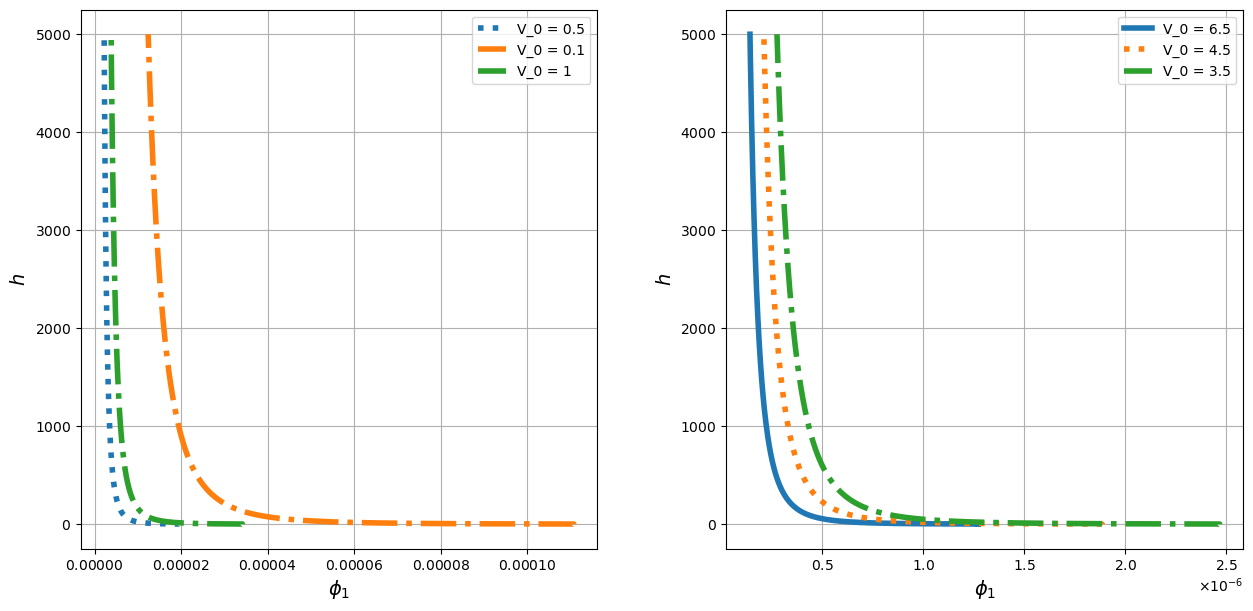

In [160]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'wspace': 0.25} )



axs[1].plot(phi_1_arr , h,   label='V_0 = 6.5', linewidth='4', linestyle='-')
axs[0].plot(phi_1_arr_1 ,  h,  label='V_0 = 0.5', linewidth='4', linestyle=':')
axs[0].plot(phi_1_arr_2 , h, label='V_0 = 0.1', linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr_5 , h, label='V_0 = 1', linewidth='4',  linestyle='-.')
axs[1].plot(phi_1_arr_3 ,  h,  label='V_0 = 4.5', linewidth='4', linestyle=':')
axs[1].plot(phi_1_arr_4 , h, label='V_0 = 3.5', linewidth='4',  linestyle='-.')

axs[0].set_ylabel('$h$', fontsize=14)
axs[0].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
axs[0].ticklabel_format(style='scientific', axis='Both', useMathText=True, useOffset=False)
axs[0].grid(True)
axs[0].legend()


axs[1].set_ylabel('$h$', fontsize=14)
axs[1].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
axs[1].ticklabel_format(style='scientific', axis='Both', useMathText=True, useOffset=False)
axs[1].grid(True)
axs[1].legend()

# plt.show()

# plt.plot( phi_1_arr, h,label='Kharadly&Jackson (100 GHz), H = 100%', linewidth='4',  linestyle='-')
# plt.xlabel('$\phi_1$')
# plt.ylabel("$h$")
# plt.grid()
# plt.show()


In [167]:
Humidity = 0
phi_1_ = C*pow(h_0/h_0,b)/(rho*pow(V_0,gamma))
eps_1_0=  (3.500 + 0.04*Humidity - 7.78*pow(Humidity,2)*1.e-4 + 5.56*pow(Humidity,3)*1.e-6) + cmath.sqrt(-1)*(1.640+ 0.02*Humidity - 3.71*pow(Humidity,2)*1.e-4 + 2.76*pow(Humidity,3)*1.e-6)

In [128]:
eps_0[2*coeff]

1.0006299278343391

In [129]:
eps_w = 3 * eps_0[2*coeff] * phi_1_* (eps_1_0 - eps_0[2*coeff]) / (eps_1_0 + 2 * eps_0[2*coeff]) + eps_0[2*coeff]
eps_w.real

NameError: name 'phi_1_' is not defined

In [170]:
eps_w.imag

8.87508288977835e-06

In [171]:
eps_kj =(2*eps_0[2*coeff]*phi_1_*(eps_1_0-eps_0[2*coeff]) + eps_0[2*coeff]*eps_1_0+ 2*eps_0[2*coeff]*eps_0[2*coeff])/(eps_1_0+2*eps_0[2*coeff]-phi_1_*(eps_1_0-eps_0[2*coeff]))
eps_kj.real

1.000659563905898

In [172]:
eps_kj.imag

8.875258128749878e-06

In [173]:
eps_l =  pow((phi_1_*(pow(eps_1_0,1.0/3.0)-pow(eps_0[2*coeff],1.0/3.0)) + pow(eps_0[2*coeff],1.0/3.0)), 3)
eps_l.real

1.0006627399039296

In [174]:
eps_l.imag

1.3566641558239712e-05

In [58]:
Humidity_0 = 0
Humidity = 100
H_max = 5000
coeff = 160
phi_1_arr = [0]*(H_max*coeff+1)
h = np.linspace(0, H_max, H_max*coeff+1)

cols = 2
eps_1_0= [(4.560 + 0.04*Humidity_0 - 7.78*pow(Humidity_0,2)*1.e-4 + 5.56*pow(Humidity_0,3)*1.e-6) + cmath.sqrt(-1)*(0.251 + 0.02*Humidity_0 - 3.71*pow(Humidity_0,2)*1.e-4 + 2.76*pow(Humidity_0,3)*1.e-6), 
        (3.500 + 0.04*Humidity_0 - 7.78*pow(Humidity_0,2)*1.e-4 + 5.56*pow(Humidity_0,3)*1.e-6) + cmath.sqrt(-1)*(1.640 + 0.02*Humidity_0 - 3.71*pow(Humidity_0,2)*1.e-4 + 2.76*pow(Humidity_0,3)*1.e-6) 
        ]
eps_1= [(4.560 + 0.04*Humidity - 7.78*pow(Humidity,2)*1.e-4 + 5.56*pow(Humidity,3)*1.e-6) + cmath.sqrt(-1)*(0.251 + 0.02*Humidity - 3.71*pow(Humidity,2)*1.e-4 + 2.76*pow(Humidity,3)*1.e-6), 
        (3.500 + 0.04*Humidity - 7.78*pow(Humidity,2)*1.e-4 + 5.56*pow(Humidity,3)*1.e-6) + cmath.sqrt(-1)*(1.640 + 0.02*Humidity- 3.71*pow(Humidity,2)*1.e-4 + 2.76*pow(Humidity,3)*1.e-6)
        ]
    
b=0.28
rho=2440.0

#visibility
V_arr = np.linspace(6.5,100.5,H_max*coeff+1) ; #meters
h_0 = 2.0

#for Libya and Sudan
gamma = 1.07
C = 2.3*1.e-2
for i in range(H_max*coeff+1):
    phi_1_arr[i] = C/(rho*pow(V_arr[i],gamma))
phi_1_arr[H_max*coeff]

6.792354179290158e-08

In [59]:
eps_w_real_0 = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_kj_real_0 = np.zeros((H_max*coeff+1,cols),dtype=complex) 
eps_l_real_0 = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_w_complex_0 = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_kj_complex_0 = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_l_complex_0 = np.zeros((H_max*coeff+1,cols),dtype=complex)

eps_w_real = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_kj_real = np.zeros((H_max*coeff+1,cols),dtype=complex) 
eps_l_real = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_w_complex = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_kj_complex = np.zeros((H_max*coeff+1,cols),dtype=complex)
eps_l_complex = np.zeros((H_max*coeff+1,cols),dtype=complex)

In [60]:
eps_0 = [0]*(H_max*coeff+1)
for i in range(H_max*coeff+1):
    eps_0[i] =  pow ((1 + (315*math.exp(-1.36 *1.e-4*h[i]))*1.e-6),2)

In [61]:
eps_w_real = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_w_real[i][j] = 3 * eps_0[i] * phi_1_arr[i] * (eps_1[j] - eps_0[i]) / (eps_1[j] + 2 * eps_0[i]) + eps_0[i]
eps_w_real = np.real(eps_w_real)


In [62]:
eps_kj_real = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_kj_real[i][j] =(2*eps_0[i]*phi_1_arr[i]*(eps_1[j]-eps_0[i]) + eps_0[i]*eps_1[j] + 2*eps_0[i]*eps_0[i])/(eps_1[j]+2*eps_0[i]-phi_1_arr[i]*(eps_1[j]-eps_0[i]))
eps_kj_real = np.real(eps_kj_real)

In [63]:
eps_l_real = np.zeros((H_max*coeff+1,cols),dtype=complex)  
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_l_real[i][j] = pow((phi_1_arr[i]*(pow(eps_1[j],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3)
eps_l_real = np.real(eps_l_real)

In [64]:
eps_w_complex = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_w_complex[i][j] = (3*eps_0[i]*phi_1_arr[i]*(eps_1[j] - eps_0[i])/(eps_1[j] + 2*eps_0[i]) + eps_0[i])
eps_w_complex = np.imag(eps_w_complex)

In [65]:
eps_kj_complex = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_kj_complex[i][j] = (2*eps_0[i]*phi_1_arr[i]*(eps_1[j]-eps_0[i]) + eps_0[i]*eps_1[j] + 2*eps_0[i]*eps_0[i])/(eps_1[j]+2*eps_0[i]-phi_1_arr[i]*(eps_1[j]-eps_0[i]))
eps_kj_complex = np.imag(eps_kj_complex)

In [66]:
eps_l_complex = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_l_complex[i][j] = (pow((phi_1_arr[i]*(pow(eps_1[j],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3))
eps_l_complex= np.imag(eps_l_complex)

In [67]:
eps_w_real_0 = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_w_real_0[i][j] = 3 * eps_0[i] * phi_1_arr[i] * (eps_1_0[j] - eps_0[i]) / (eps_1_0[j] + 2 * eps_0[i]) + eps_0[i]
eps_w_real_0 = np.real(eps_w_real_0)


In [68]:
eps_kj_real_0 = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_kj_real_0[i][j] =(2*eps_0[i]*phi_1_arr[i]*(eps_1_0[j]-eps_0[i]) + eps_0[i]*eps_1_0[j] + 2*eps_0[i]*eps_0[i])/(eps_1_0[j]+2*eps_0[i]-phi_1_arr[i]*(eps_1_0[j]-eps_0[i]))
eps_kj_real_0 = np.real(eps_kj_real_0)

In [69]:
eps_l_real_0 = np.zeros((H_max*coeff+1,cols),dtype=complex)  
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_l_real_0[i][j] = pow((phi_1_arr[i]*(pow(eps_1_0[j],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3)
eps_l_real_0 = np.real(eps_l_real_0)

In [70]:
eps_w_complex_0 = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_w_complex_0[i][j] = (3*eps_0[i]*phi_1_arr[i]*(eps_1_0[j] - eps_0[i])/(eps_1_0[j] + 2*eps_0[i]) + eps_0[i])
eps_w_complex_0 = np.imag(eps_w_complex_0)

In [71]:
eps_kj_complex_0 = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_kj_complex_0[i][j] = (2*eps_0[i]*phi_1_arr[i]*(eps_1_0[j]-eps_0[i]) + eps_0[i]*eps_1_0[j] + 2*eps_0[i]*eps_0[i])/(eps_1_0[j]+2*eps_0[i]-phi_1_arr[i]*(eps_1_0[j]-eps_0[i]))
eps_kj_complex_0 = np.imag(eps_kj_complex_0)

In [72]:
eps_l_complex_0 = np.zeros((H_max*coeff+1,cols),dtype=complex) 
for i in range(H_max * coeff + 1):
    for j in range(cols):
        eps_l_complex_0[i][j] = (pow((phi_1_arr[i]*(pow(eps_1_0[j],1.0/3.0)-pow(eps_0[i],1.0/3.0)) + pow(eps_0[i],1.0/3.0)), 3))
eps_l_complex_0= np.imag(eps_l_complex_0)

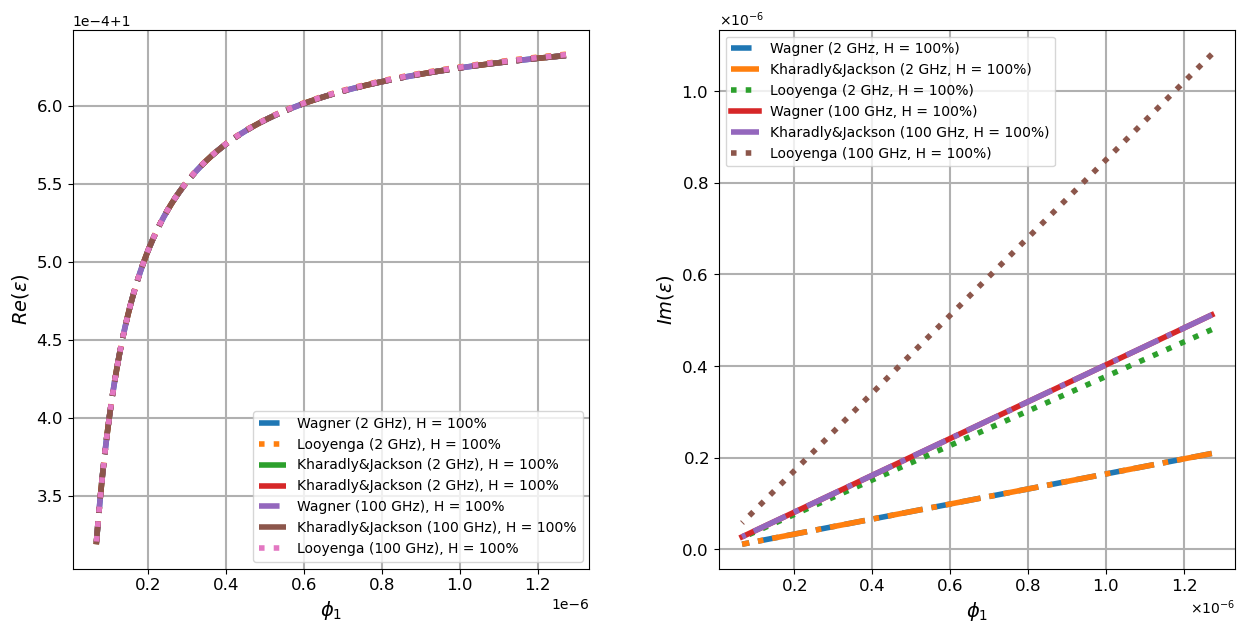

In [73]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'wspace': 0.25} )


# axs[0].plot(eps_0, h,  label='$ε_0$', linewidth='4', linestyle='-')
# axs[0].plot(phi_1_arr ,  eps_w_real_0[:, 0],   label='Wagner (2 GHz, H = 0%)', linewidth='4', linestyle='--')
# axs[0].plot(phi_1_arr ,  eps_l_real_0[:,0],  label='Looyenga (2 GHz, H = 0%)', linewidth='4', linestyle=':')
# axs[0].plot(phi_1_arr , eps_kj_real_0[:,0], label='Kharadly&Jackson (2 GHz, H = 0%)', linewidth='4',  linestyle='-.')


# axs[0].plot(phi_1_arr , eps_w_real_0[:,1],   label='Wagner (100 GHz, H = 0%)', linewidth='4', linestyle='--')
# axs[0].plot(phi_1_arr , eps_kj_real_0[:,1], label='Kharadly&Jackson (100 GHz, H = 0%)', linewidth='4',  linestyle='-.')
# axs[0].plot(phi_1_arr , eps_l_real_0[:,1],   label='Looyenga (100 GHz, H = 0%)', linewidth='4', linestyle=':')


axs[0].plot(phi_1_arr ,  eps_w_real[:, 0],   label='Wagner (2 GHz), H = 100%', linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr ,  eps_l_real[:,0],  label='Looyenga (2 GHz), H = 100%', linewidth='4', linestyle=':')
axs[0].plot(phi_1_arr , eps_kj_real[:,0], label='Kharadly&Jackson (2 GHz), H = 100%', linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr , eps_kj_real[:,0], label='Kharadly&Jackson (2 GHz), H = 100%', linewidth='4',  linestyle='-.')


axs[0].plot(phi_1_arr , eps_w_real[:,1],   label='Wagner (100 GHz), H = 100%', linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr , eps_kj_real[:,1], label='Kharadly&Jackson (100 GHz), H = 100%', linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr , eps_l_real[:,1],   label='Looyenga (100 GHz), H = 100%', linewidth='4', linestyle=':')

axs[0].set_ylabel('$Re(ε)$', fontsize=14)
axs[0].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
# axs[0].set_xlim(1.4, 1.5)
#axs[0].set_title('Стандартная рефракция без пыли')
axs[0].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[0].ticklabel_format(style='sci', axis='Both', scilimits=(0,0))  # Представление значений на оси x в экспоненциальной форме
axs[0].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[0].legend()



axs[1].plot(phi_1_arr , eps_w_complex[:,0],   label='Wagner (2 GHz, H = 100%)', linewidth='4', linestyle='--')
axs[1].plot(phi_1_arr , eps_kj_complex[:,0],  label='Kharadly&Jackson (2 GHz, H = 100%)', linewidth='4', linestyle='-.')
axs[1].plot(phi_1_arr , eps_l_complex[:,0], label='Looyenga (2 GHz, H = 100%)', linewidth='4', linestyle=':')



axs[1].plot(phi_1_arr , eps_w_complex[:,1],  label='Wagner (100 GHz, H = 100%)', linewidth='4', linestyle='-')
axs[1].plot(phi_1_arr ,  eps_kj_complex[:,1], label='Kharadly&Jackson (100 GHz, H = 100%)', linewidth='4', linestyle='-.')
axs[1].plot(phi_1_arr ,  eps_l_complex[:,1],  label='Looyenga (100 GHz, H = 100%)', linewidth='4', linestyle=':')



# axs[1].plot(phi_1_arr , eps_w_complex_0[:,0],   label='Wagner (2 GHz, H = 0%)', linewidth='4', linestyle='--')
# axs[1].plot(phi_1_arr , eps_kj_complex_0[:,0],  label='Kharadly&Jackson (2 GHz, H = 0%)', linewidth='4', linestyle='-.')
# axs[1].plot(phi_1_arr , eps_l_complex_0[:,0], label='Looyenga (2 GHz, H = 0%)', linewidth='4', linestyle=':')



# axs[1].plot(phi_1_arr , eps_w_complex_0[:,1],  label='Wagner (100 GHz, H = 0%)', linewidth='4', linestyle='-')
# axs[1].plot(phi_1_arr ,  eps_kj_complex_0[:,1], label='Kharadly&Jackson (100 GHz, H = 0%)', linewidth='4', linestyle='-.')
# axs[1].plot(phi_1_arr ,  eps_l_complex_0[:,1],  label='Looyenga (100 GHz, H = 0%)', linewidth='4', linestyle=':')


axs[1].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
axs[1].set_ylabel('$Im(ε)$', fontsize=14)
# axs[1].set_xlim(0, 0.4)
# axs[1].set_title()
axs[1].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[1].ticklabel_format(style='sci', axis='Both', scilimits=(0,0),  useMathText=True, useOffset=False)  # Представление значений на оси x в экспоненциальной форме
axs[1].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[1].legend()

plt.show()


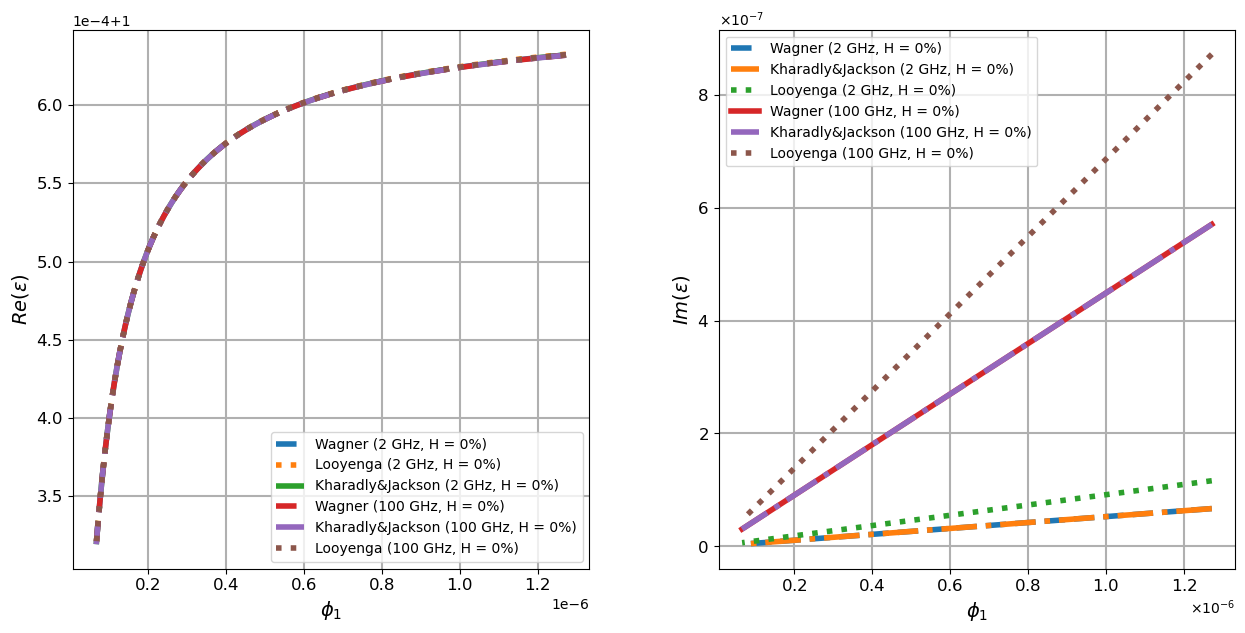

In [74]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'wspace': 0.25} )


# axs[0].plot(eps_0, h,  label='$ε_0$', linewidth='4', linestyle='-')
axs[0].plot(phi_1_arr ,  eps_w_real_0[:, 0],   label='Wagner (2 GHz, H = 0%)', linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr ,  eps_l_real_0[:,0],  label='Looyenga (2 GHz, H = 0%)', linewidth='4', linestyle=':')
axs[0].plot(phi_1_arr , eps_kj_real_0[:,0], label='Kharadly&Jackson (2 GHz, H = 0%)', linewidth='4',  linestyle='-.')


axs[0].plot(phi_1_arr , eps_w_real_0[:,1],   label='Wagner (100 GHz, H = 0%)', linewidth='4', linestyle='--')
axs[0].plot(phi_1_arr , eps_kj_real_0[:,1], label='Kharadly&Jackson (100 GHz, H = 0%)', linewidth='4',  linestyle='-.')
axs[0].plot(phi_1_arr , eps_l_real_0[:,1],   label='Looyenga (100 GHz, H = 0%)', linewidth='4', linestyle=':')


# axs[0].plot(phi_1_arr ,  eps_w_real[:, 0],   label='Wagner (2 GHz), H = 100%', linewidth='4', linestyle='--')
# axs[0].plot(phi_1_arr ,  eps_l_real[:,0],  label='Looyenga (2 GHz), H = 100%', linewidth='4', linestyle=':')
# axs[0].plot(phi_1_arr , eps_kj_real[:,0], label='Kharadly&Jackson (2 GHz), H = 100%', linewidth='4',  linestyle='-.')
# axs[0].plot(phi_1_arr , eps_kj_real[:,0], label='Kharadly&Jackson (2 GHz), H = 100%', linewidth='4',  linestyle='-.')


# axs[0].plot(phi_1_arr , eps_w_real[:,1],   label='Wagner (100 GHz), H = 100%', linewidth='4', linestyle='--')
# axs[0].plot(phi_1_arr , eps_kj_real[:,1], label='Kharadly&Jackson (100 GHz), H = 100%', linewidth='4',  linestyle='-.')
# axs[0].plot(phi_1_arr , eps_l_real[:,1],   label='Looyenga (100 GHz), H = 100%', linewidth='4', linestyle=':')

axs[0].set_ylabel('$Re(ε)$', fontsize=14)
axs[0].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
# axs[0].set_xlim(1.4, 1.5)
#axs[0].set_title('Стандартная рефракция без пыли')
axs[0].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[0].ticklabel_format(style='sci', axis='Both', scilimits=(0,0))  # Представление значений на оси x в экспоненциальной форме
axs[0].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[0].legend()



# axs[1].plot(phi_1_arr , eps_w_complex[:,0],   label='Wagner (2 GHz, H = 100%)', linewidth='4', linestyle='--')
# axs[1].plot(phi_1_arr , eps_kj_complex[:,0],  label='Kharadly&Jackson (2 GHz, H = 100%)', linewidth='4', linestyle='-.')
# axs[1].plot(phi_1_arr , eps_l_complex[:,0], label='Looyenga (2 GHz, H = 100%)', linewidth='4', linestyle=':')



# axs[1].plot(phi_1_arr , eps_w_complex[:,1],  label='Wagner (100 GHz, H = 100%)', linewidth='4', linestyle='-')
# axs[1].plot(phi_1_arr ,  eps_kj_complex[:,1], label='Kharadly&Jackson (100 GHz, H = 100%)', linewidth='4', linestyle='-.')
# axs[1].plot(phi_1_arr ,  eps_l_complex[:,1],  label='Looyenga (100 GHz, H = 100%)', linewidth='4', linestyle=':')



axs[1].plot(phi_1_arr , eps_w_complex_0[:,0],   label='Wagner (2 GHz, H = 0%)', linewidth='4', linestyle='--')
axs[1].plot(phi_1_arr , eps_kj_complex_0[:,0],  label='Kharadly&Jackson (2 GHz, H = 0%)', linewidth='4', linestyle='-.')
axs[1].plot(phi_1_arr , eps_l_complex_0[:,0], label='Looyenga (2 GHz, H = 0%)', linewidth='4', linestyle=':')



axs[1].plot(phi_1_arr , eps_w_complex_0[:,1],  label='Wagner (100 GHz, H = 0%)', linewidth='4', linestyle='-')
axs[1].plot(phi_1_arr ,  eps_kj_complex_0[:,1], label='Kharadly&Jackson (100 GHz, H = 0%)', linewidth='4', linestyle='-.')
axs[1].plot(phi_1_arr ,  eps_l_complex_0[:,1],  label='Looyenga (100 GHz, H = 0%)', linewidth='4', linestyle=':')


axs[1].set_xlabel('$\phi_1$', fontsize=14) #, labelpad=18)
axs[1].set_ylabel('$Im(ε)$', fontsize=14)
# axs[1].set_xlim(0, 0.4)
# axs[1].set_title()
axs[1].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[1].ticklabel_format(style='sci', axis='Both', scilimits=(0,0),  useMathText=True, useOffset=False)  # Представление значений на оси x в экспоненциальной форме
axs[1].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[1].legend()

plt.show()


c:\conda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


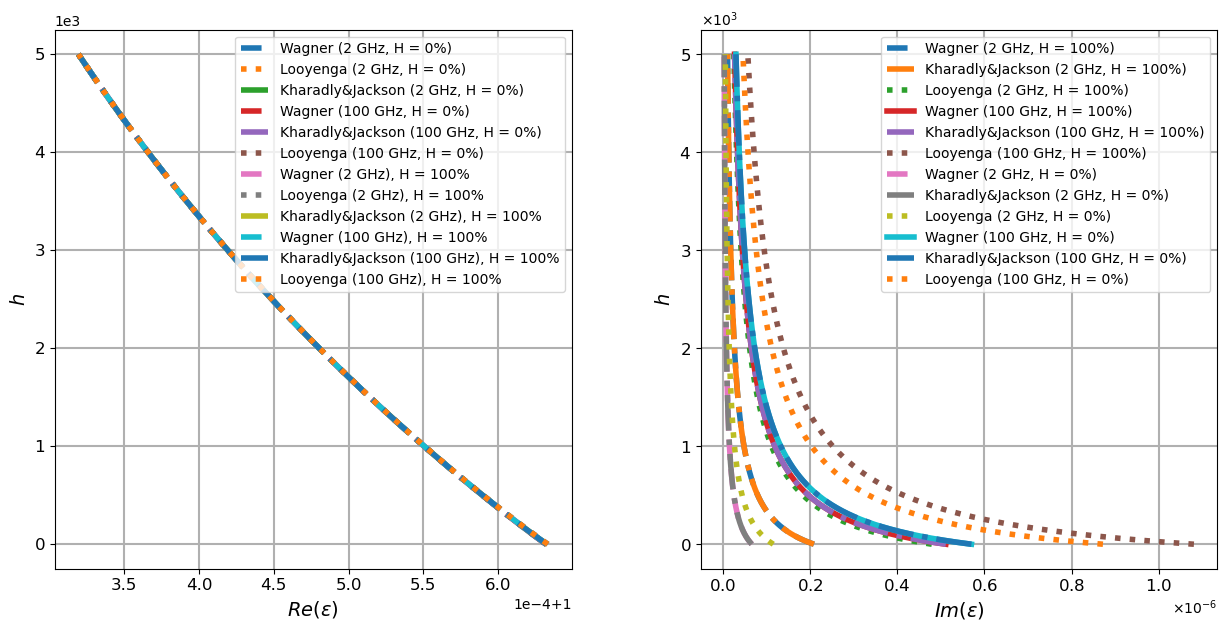

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'wspace': 0.25} )


# axs[0].plot(eps_0, h,  label='$ε_0$', linewidth='4', linestyle='-')
axs[0].plot(  eps_w_real_0[:, 0], h,  label='Wagner (2 GHz, H = 0%)', linewidth='4', linestyle='--')
axs[0].plot(  eps_l_real_0[:,0], h, label='Looyenga (2 GHz, H = 0%)', linewidth='4', linestyle=':')
axs[0].plot( eps_kj_real_0[:,0], h,label='Kharadly&Jackson (2 GHz, H = 0%)', linewidth='4',  linestyle='-.')


axs[0].plot( eps_w_real_0[:,1], h,  label='Wagner (100 GHz, H = 0%)', linewidth='4', linestyle='--')
axs[0].plot( eps_kj_real_0[:,1],h, label='Kharadly&Jackson (100 GHz, H = 0%)', linewidth='4',  linestyle='-.')
axs[0].plot( eps_l_real_0[:,1], h,  label='Looyenga (100 GHz, H = 0%)', linewidth='4', linestyle=':')


axs[0].plot( eps_w_real[:, 0], h,  label='Wagner (2 GHz), H = 100%', linewidth='4', linestyle='--')
axs[0].plot(  eps_l_real[:,0], h, label='Looyenga (2 GHz), H = 100%', linewidth='4', linestyle=':')
axs[0].plot( eps_kj_real[:,0], h,label='Kharadly&Jackson (2 GHz), H = 100%', linewidth='4',  linestyle='-.')


axs[0].plot( eps_w_real[:,1],  h, label='Wagner (100 GHz), H = 100%', linewidth='4', linestyle='--')
axs[0].plot( eps_kj_real[:,1], h,label='Kharadly&Jackson (100 GHz), H = 100%', linewidth='4',  linestyle='-.')
axs[0].plot( eps_l_real[:,1],  h, label='Looyenga (100 GHz), H = 100%', linewidth='4', linestyle=':')

axs[0].set_ylabel('$h$', fontsize=14)
axs[0].set_xlabel('$Re(ε)$', fontsize=14) #, labelpad=18)
# axs[0].set_xlim(1.4, 1.5)
#axs[0].set_title('Стандартная рефракция без пыли')
axs[0].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[0].ticklabel_format(style='sci', axis='Both', scilimits=(0,0))  # Представление значений на оси x в экспоненциальной форме
axs[0].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[0].legend()



axs[1].plot( eps_w_complex[:,0],  h, label='Wagner (2 GHz, H = 100%)', linewidth='4', linestyle='--')
axs[1].plot( eps_kj_complex[:,0],h,  label='Kharadly&Jackson (2 GHz, H = 100%)', linewidth='4', linestyle='-.')
axs[1].plot( eps_l_complex[:,0],h, label='Looyenga (2 GHz, H = 100%)', linewidth='4', linestyle=':')



axs[1].plot( eps_w_complex[:,1], h, label='Wagner (100 GHz, H = 100%)', linewidth='4', linestyle='-')
axs[1].plot( eps_kj_complex[:,1], h,label='Kharadly&Jackson (100 GHz, H = 100%)', linewidth='4', linestyle='-.')
axs[1].plot(  eps_l_complex[:,1], h, label='Looyenga (100 GHz, H = 100%)', linewidth='4', linestyle=':')



axs[1].plot( eps_w_complex_0[:,0], h,  label='Wagner (2 GHz, H = 0%)', linewidth='4', linestyle='--')
axs[1].plot( eps_kj_complex_0[:,0], h, label='Kharadly&Jackson (2 GHz, H = 0%)', linewidth='4', linestyle='-.')
axs[1].plot(eps_l_complex_0[:,0],h, label='Looyenga (2 GHz, H = 0%)', linewidth='4', linestyle=':')



axs[1].plot( eps_w_complex_0[:,1], h, label='Wagner (100 GHz, H = 0%)', linewidth='4', linestyle='-')
axs[1].plot( eps_kj_complex_0[:,1], h,label='Kharadly&Jackson (100 GHz, H = 0%)', linewidth='4', linestyle='-.')
axs[1].plot( eps_l_complex_0[:,1], h, label='Looyenga (100 GHz, H = 0%)', linewidth='4', linestyle=':')


axs[1].set_xlabel('$Im(ε)$', fontsize=14) #, labelpad=18)
axs[1].set_ylabel('$h$', fontsize=14)
# axs[1].set_xlim(0, 0.4)
# axs[1].set_title()
axs[1].tick_params(axis='both', which='major', labelsize=12)  # Увеличение размера цифр на осях
axs[1].ticklabel_format(style='sci', axis='Both', scilimits=(0,0),  useMathText=True, useOffset=False)  # Представление значений на оси x в экспоненциальной форме
axs[1].grid(True, linewidth=1.5)  # Увеличение толщины сетки
axs[1].legend()

plt.show()

<span style="font-size: 48px;">Field calculations</span>

In [278]:
data = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid30_h20_0tilt_NEW.txt",encoding='utf-8').transpose() 

In [267]:
data1 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid100_h0_0tilt.txt",encoding='utf-8').transpose() 

In [259]:
data2 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid30_h0_0tilt.txt",encoding='utf-8').transpose() 

In [260]:
data3 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid100_h60_0tilt.txt",encoding='utf-8').transpose() 

In [261]:
data4 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid6.5_h0_0tilt.txt",encoding='utf-8').transpose() 

In [262]:
data5 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid6.5_h60_0tilt.txt",encoding='utf-8').transpose() 

In [263]:
data6= np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid6.5_h20_0tilt.txt",encoding='utf-8').transpose() 

In [268]:
data7 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid100_h20_0tilt.txt",encoding='utf-8').transpose() 

In [269]:
data8 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid100_h40_0tilt.txt",encoding='utf-8').transpose() 

In [270]:
data9 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid30_h20_0tilt.txt",encoding='utf-8').transpose() 

In [264]:
data10 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid30_h40_0tilt.txt",encoding='utf-8').transpose() 

In [271]:
data11 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid6.5_h40_0tilt.txt",encoding='utf-8').transpose() 

In [266]:
data12 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid30_h60_0tilt.txt",encoding='utf-8').transpose() 

In [232]:
data13 = np.genfromtxt(r"C:\\GitHub\\pe_radiowaves\\field10ghz_vid30_h20_0tilt.txt",encoding='utf-8').transpose()   

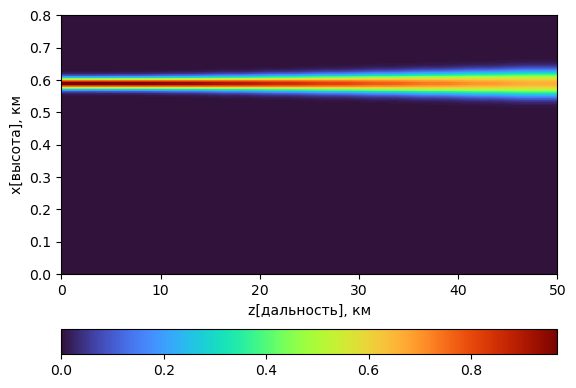

In [244]:
height = 800 #(2000/7500)*200
distance = 50000 #(50000/16810)*500
plt.imshow(data13[160:300, 0:10], aspect="auto", origin='lower', cmap='turbo' , extent=[0, distance/1000, 0, height/1000])
plt.xlabel('z[дальность], км')
plt.ylabel('x[высота], км') 
plt.colorbar(orientation='horizontal')
plt.show()

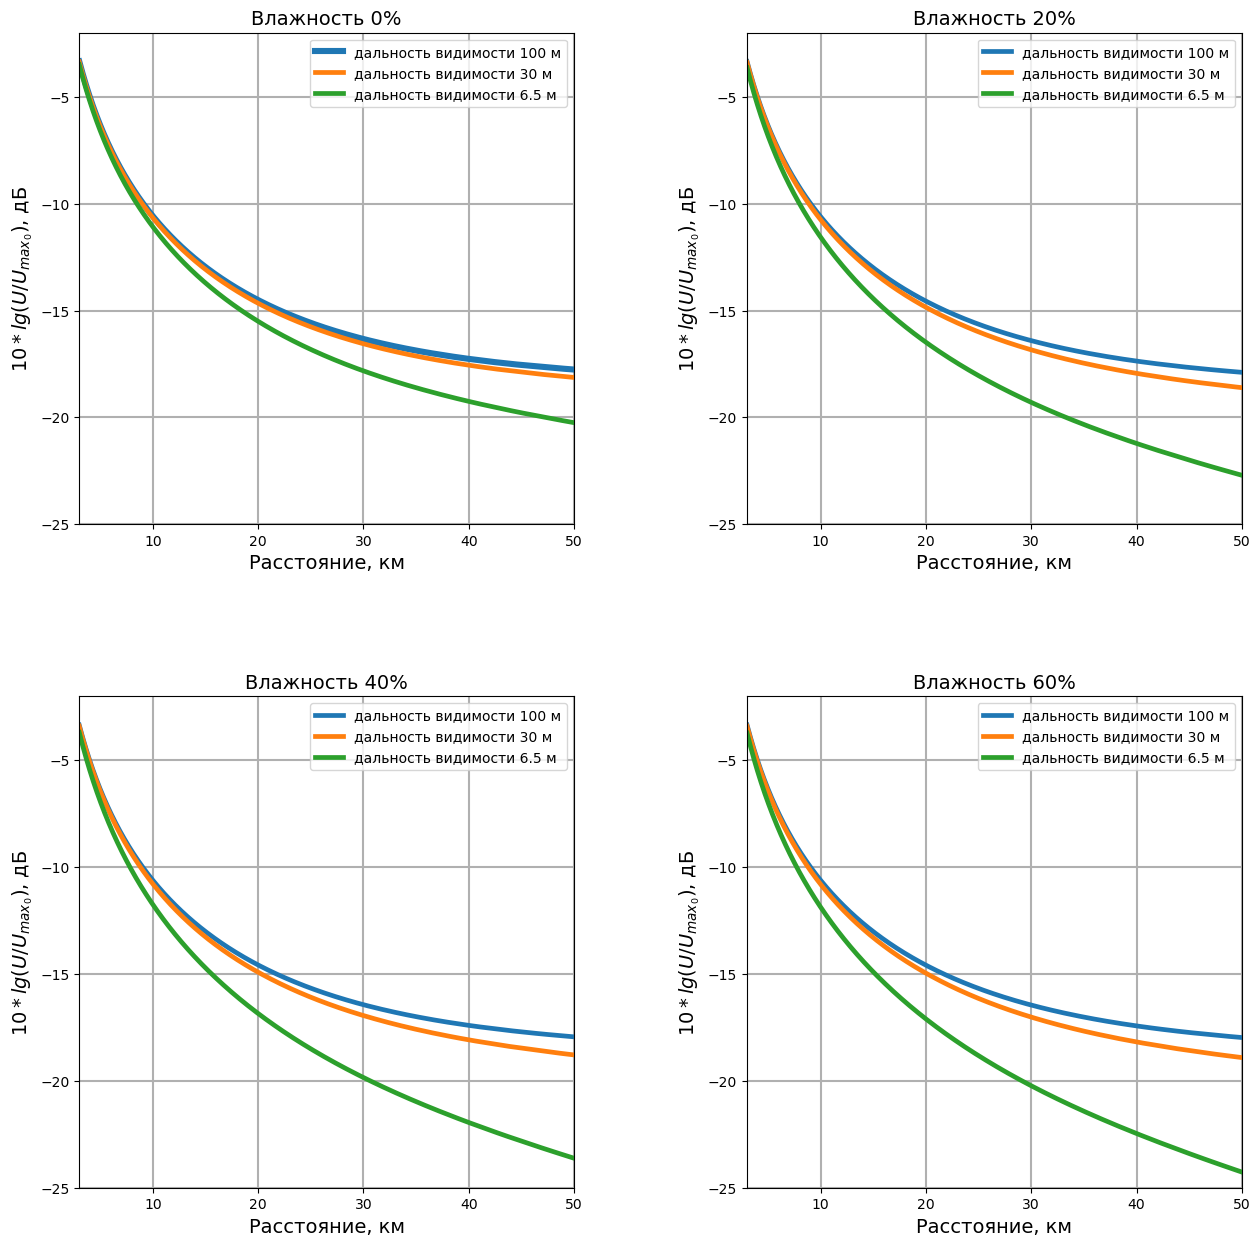

In [279]:
dist = np.linspace(0,50,19999)



fig, axs = plt.subplots(2, 2, figsize=(15, 15), gridspec_kw={'wspace': 0.35} )
fig.subplots_adjust(hspace=0.35)  # Увеличиваем вертикальное расстояние между subplot'ами



axs[0,0].plot(dist, 10*np.log10(data1/0.056580), linewidth=4.4, label="дальность видимости 100 м")
axs[0,0].plot(dist, 10*np.log10(data2/0.056580),  linewidth=3.4, label="дальность видимости 30 м")
axs[0,0].plot(dist, 10*np.log10(data4/0.056580), linewidth=3.4,  label="дальность видимости 6.5 м")
axs[0,0].set_xlabel('Расстояние, км',fontsize=14)
axs[0,0].set_ylabel("$10*lg (U/U_{max_0}$), дБ",fontsize=14)
axs[0,0].set_title("Влажность 0%",fontsize=14)
axs[0,0].grid(True, linewidth=1.5)
axs[0,0].legend(loc='best')
axs[0,0].set_xlim(3,50)
axs[0,0].set_ylim(-25,-2)


axs[0,1].plot(dist, 10*np.log10(data7/0.056580), linewidth=3.4, label="дальность видимости 100 м")
axs[0,1].plot(dist, 10*np.log10(data/0.056580), linewidth=3.4,  label="дальность видимости 30 м")
axs[0,1].plot(dist, 10*np.log10(data6/0.056580), linewidth=3.4,  label="дальность видимости 6.5 м")
axs[0,1].set_xlabel('Расстояние, км',fontsize=14)
axs[0,1].set_ylabel("$10*lg (U/U_{max_0}$), дБ",fontsize=14)
axs[0,1].set_title("Влажность 20%",fontsize=14)
axs[0,1].grid(True, linewidth=1.5)
axs[0,1].legend(loc='best')
axs[0,1].set_xlim(3,50)
axs[0,1].set_ylim(-25,-2)


axs[1,0].plot(dist, 10*np.log10(data8/0.056580), linewidth=3.4, label="дальность видимости 100 м")
axs[1,0].plot(dist, 10*np.log10(data10/0.056580), linewidth=3.4, label="дальность видимости 30 м")
axs[1,0].plot(dist, 10*np.log10(data11/0.056580), linewidth=3.4, label="дальность видимости 6.5 м")
axs[1,0].set_xlabel('Расстояние, км',fontsize=14)
axs[1,0].set_ylabel("$10*lg (U/U_{max_0}$), дБ",fontsize=14)
axs[1,0].set_title("Влажность 40%",fontsize=14)
axs[1,0].grid(True, linewidth=1.5)
axs[1,0].legend(loc='best')
axs[1,0].set_xlim(3,50)
axs[1,0].set_ylim(-25,-2)


axs[1,1].plot(dist, 10*np.log10(data3/0.056580), linewidth=3.4, label="дальность видимости 100 м")
axs[1,1].plot(dist, 10*np.log10(data12/0.056580), linewidth=3.4, label="дальность видимости 30 м")
axs[1,1].plot(dist, 10*np.log10(data5/0.056580), linewidth=3.4, label="дальность видимости 6.5 м")
axs[1,1].set_xlabel('Расстояние, км',fontsize=14)
axs[1,1].set_ylabel("$10*lg (U/U_{max_0}$), дБ",fontsize=14)
axs[1,1].set_title("Влажность 60%",fontsize=14)
axs[1,1].grid(True, linewidth=1.5)
axs[1,1].legend(loc='best')
axs[1,1].set_xlim(3,50)
axs[1,1].set_ylim(-25,-2)


 # Plotting both the curves imultaneously 
# plt.figure(figsize=(7,10))
# plt.plot(dist, 10*np.log10(data1/0.108401), linestyle='-',linewidth='2.4',  label='дальность видимости 100 м, H = 0%') 
# plt.plot(dist, 10*np.log10(data2/0.108401), linestyle='-',linewidth='2.4',  label='дальность видимости 30 м, H = 0%') 
# plt.plot(dist, 10*np.log10(data3/0.108401),  linestyle='-',linewidth='2.4',  label='дальность видимости 10 м, H = 0%')
# plt.plot(dist, 10*np.log10(data4/0.108401),  linestyle=':',linewidth='2.4',  label='дальность видимости 6.5 м, H = 0%')
# plt.plot(dist, 10*np.log10(data5/0.108401),  linestyle='-',linewidth='2.4',  label='дальность видимости 6.5 м, H = 60%')
# plt.plot(dist, 10*np.log10(data6/0.108401),  linestyle='-',linewidth='2.4',  label= видимости 6.5 м, H = 20%')
# plt.plot(dist, 10*np.log10(data7/0.108401),  linestyle=':', color="black", linewidth='2.4',  label='дальность видимости 100 м, H = 20%')




plt.show() 

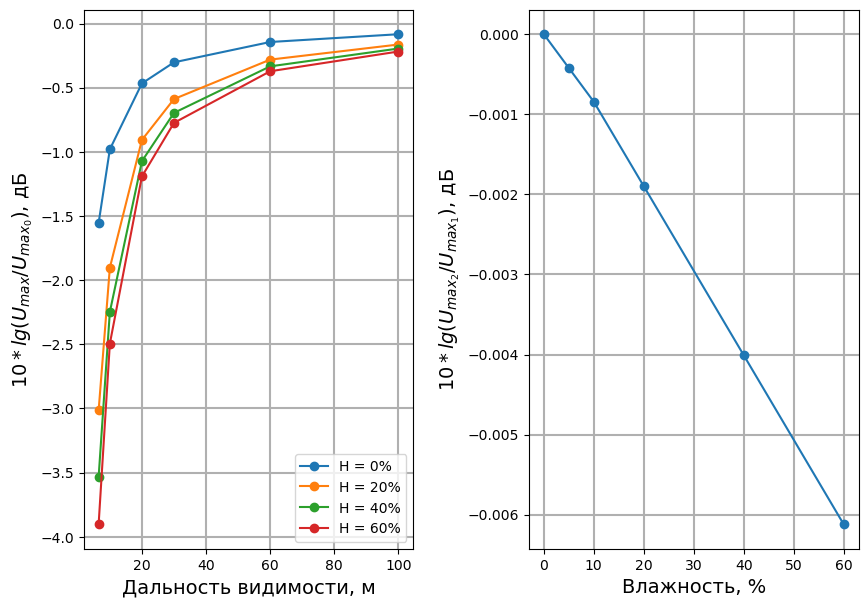

In [168]:

#для спутника
def path_loss(x):
    return 10*math.log10(x/0.020598)

def withHum(y):
    return 10*math.log10(y)
    
# Пример данных для осей x и y
x_values = [98292.682927/1000,98138.013087/1000, 98132.064247/1000, 98132.064247/1000, 98155.859607/1000, 98138.013087/1000, 98161.808447/1000]
y_values = [path_loss(0.020691), path_loss(0.020206), path_loss(0.019212), path_loss(0.016436), path_loss(0.019836), path_loss(0.019694), path_loss(0.019589)]

x_without=[0]
y_without = [path_loss(0.020691)]



x_visibility = [6.5 ,10, 20 , 30, 60, 100]

y_visibility = [path_loss(0.014401) ,path_loss(0.016436),path_loss(0.018499), path_loss(0.019212), path_loss(0.019926), path_loss(0.020206)]

y_visibility_20 = [path_loss(0.010286),path_loss(0.013290),path_loss(0.016714),path_loss(0.017987),path_loss(0.019306),path_loss(0.019836)]

y_visibility_40 = [path_loss(0.009130), path_loss(0.012276), path_loss(0.016090), path_loss(0.017546), path_loss(0.019074), path_loss(0.019694)]

y_visibility_60 = [path_loss(0.008387), path_loss(0.011597), path_loss(0.015655), path_loss(0.017234), path_loss(0.018907),path_loss(0.019589)]


fig, axs = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw={'wspace': 0.35} )

axs[0].plot(x_visibility, y_visibility, marker='o',  label="H = 0%")

axs[0].plot(x_visibility, y_visibility_20, marker='o',  label="H = 20%")

axs[0].plot(x_visibility, y_visibility_40, marker='o',  label="H = 40%")

axs[0].plot(x_visibility, y_visibility_60, marker='o',  label="H = 60%")

axs[0].legend(loc='best')

axs[0].set_xlabel("Дальность видимости, м",fontsize=14)
axs[0].set_ylabel("$10*lg (U_{max}/U_{max_0}$), дБ",fontsize=14)
axs[0].grid(True, linewidth=1.5)


x_hum = [0, 5,10, 20, 40, 60]
y_hum = [withHum(0.020598/0.020598), withHum(0.020596/0.020598), withHum(0.020594/0.020598), withHum(0.020589/0.020598), withHum(0.020579/0.020598), withHum(0.020569/0.020598)] #, withHum(/0.020691), withHum(/0.020691), withHum(/0.020691)]
# y_hum = [0.020598,0.020598,0.020596,0.020594,0.020589,0.020579,0.020569]

axs[1].plot(x_hum, y_hum, marker='o')
axs[1].set_xlabel("Влажность, %",fontsize=14)
axs[1].set_ylabel("$10*lg (U_{max_2}/U_{max_1}$), дБ",fontsize=14)
# axs[1].set_title("")

# Добавление легенды

axs[1].grid(True, linewidth=1.5)  # Увеличение толщины сетки
# Отображение графика
plt.show()

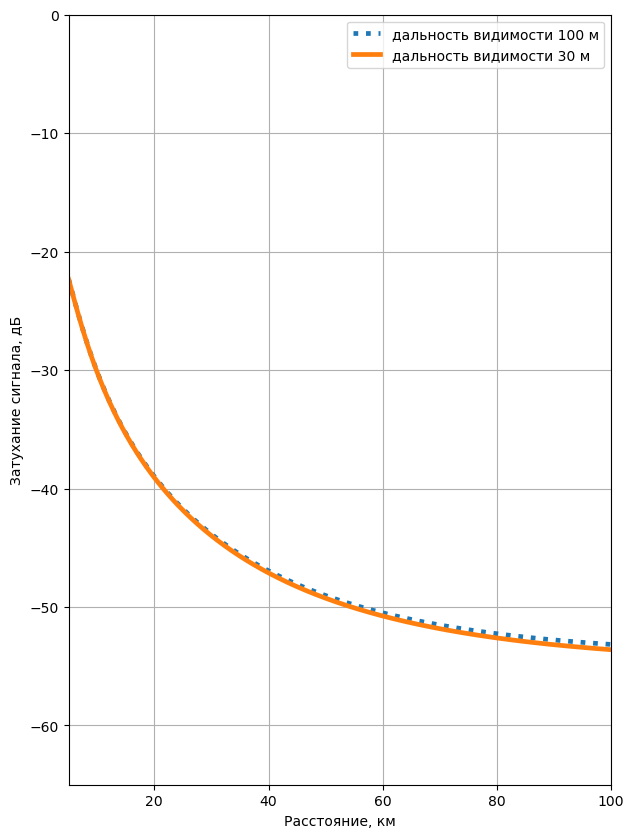

In [50]:
import array as arr 
# numbers = arr.array('d', data[:, round(350/1000/5000)])
index = 1 #round(0.75*(N_x))-1
# numbers1 = arr.array('d', path_loss[index,:])
# #numbers2 = arr.array('d', data2[:,round(350/1000/1000)])
# numbers3 = arr.array('d', path_loss3[index,:])
numbers7 = arr.array('d', path_loss7[index,:])
# numbers4 = arr.array('d', path_loss4[index,:])
# numbers5 = arr.array('d', path_loss5[index,:])
# numbers6 = arr.array('d', path_loss6[index,:])
numbers8 = arr.array('d', path_loss8[index,:])

x = np.linspace(0,100,N_z)


 # Plotting both the curves simultaneously 
plt.figure(figsize=(7,10))
# plt.plot(numbers, y, linestyle='-',linewidth='1.4',  label='dz = 0.2 м') #0
# plt.plot(x,numbers1, linestyle=':', linewidth='1.4', label='дальность видимости 30 м') 
# # plt.plot(numbers2, y, linestyle='-', linewidth='1.4',color='b',  label='dz = 1 м')
# plt.plot(x, numbers3, linestyle='-', linewidth='1.4',  label='дальность видимости 10 м') 
# plt.plot(x, numbers4, linestyle='--', linewidth='1.5',color='violet', label='дальность видимости 100 м')
plt.plot(x, numbers7, linestyle=':',linewidth='3.4',  label='дальность видимости 100 м') 
# plt.plot(x, numbers5, linestyle='-.',linewidth='1.4',  label='без пыли') 
# plt.plot(x, numbers6,  linestyle='-',linewidth='1.4',  label='без пыли')
plt.plot(x, numbers8,  linestyle='-',linewidth='3.4',  label='дальность видимости 30 м')

plt.xlabel('Расстояние, км')
plt.ylabel('Затухание сигнала, дБ')
plt.xlim(5,100)
plt.ylim(-65,0)
# plt.xticks(x, np.linspace(0, 250, N_z))
  
# Adding legend, which helps us recognize the curve according to it's color 
plt.legend() 
  
# To load the display window 
plt.grid() 
plt.show() 

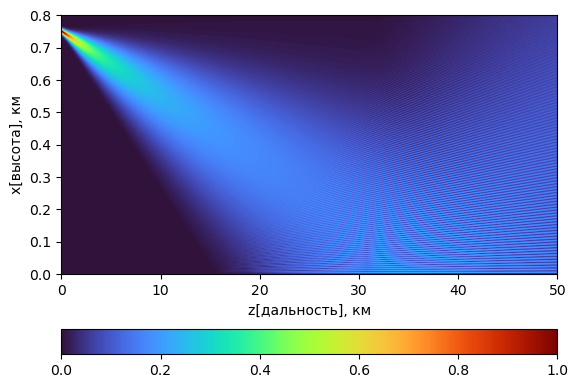

In [ ]:
height = 800 #(2000/7500)*200
distance = 50000 #(50000/16810)*500
plt.imshow(data8[0:400,0:1000], aspect="auto", origin='lower', cmap='turbo' , extent=[0, distance/1000, 0, height/1000])
plt.xlabel('z[дальность], км')
plt.ylabel('x[высота], км') 
plt.colorbar(orientation='horizontal')
plt.show()

In [115]:
height = 800
distance = 250000
source_frequency = 3.e9
z_begin = 0
N_z = 42000
N_x = 2000
dz = (distance - z_begin)/N_z
path_loss = np.zeros((round(0.75*N_x),N_z))

for i in range(round(0.75*N_x)):
    for j in range(N_z):
        if (j == 0 or data1[i][j]==0):
            path_loss[i][j] = np.nan
        else:
            current_z = z_begin + dz * j
            path_loss[i][j] = 20*math.log10(data1[i][j]) #142.0 + 20.0*math.log10(source_frequency/1.E6) - data1[i][j]
        #path_loss[i][j] = -20.0*math.log10(data1[i][j]) + 20.0*math.log10(4.0*math.pi) + 10.0*math.log10(current_z)-30*math.log10(3.e8/source_frequency)
    
# plt.imshow(path_loss,  aspect='auto', origin='lower', cmap='turbo_r' ) #extent=[0, distance/1000, 0, height/1000],
# plt.xlabel('z[дальность], км')
# plt.ylabel('x[высота], км') 
# plt.colorbar(orientation='horizontal')
# plt.show()

KeyboardInterrupt: 

In [28]:
height = 800
distance = 250000
source_frequency = 3.e9
z_begin = 0
N_z = 42000
N_x = 2000
dz = (distance - z_begin)/N_z
path_loss3 = np.zeros((round(0.75*N_x),N_z))

for i in range(round(0.75*N_x)):
    for j in range(N_z):
        if (j == 0 or data3[i][j]==0):
            path_loss3[i][j] = np.nan
        else:
            current_z = z_begin + dz * j
            path_loss3[i][j] = 20*math.log10(data3[i][j]) #142.0 + 20.0*math.log10(source_frequency/1.E6) - data1[i][j]

In [30]:
height = 800
distance = 250000
source_frequency = 3.e9
z_begin = 0
N_z = 42000
N_x = 2000
dz = (distance - z_begin)/N_z
path_loss4 = np.zeros((round(0.75*N_x),N_z))

for i in range(round(0.75*N_x)):
    for j in range(N_z):
        if (j == 0 or data4[i][j]==0):
            path_loss4[i][j] = np.nan
        else:
            current_z = z_begin + dz * j
            path_loss4[i][j] = 20*math.log10(data4[i][j]) #142.0 + 20.0*math.log10(source_frequency/1.E6) - data1[i][j]

In [36]:
height = 800
distance = 250000
source_frequency = 3.e9
z_begin = 0
N_z = 42000
N_x = 2000
dz = (distance - z_begin)/N_z
path_loss5 = np.zeros((round(0.75*N_x),N_z))

for i in range(round(0.75*N_x)):
    for j in range(N_z):
        if (j == 0 or data5[i][j]==0):
            path_loss5[i][j] = np.nan
        else:
            current_z = z_begin + dz * j
            path_loss5[i][j] = 20*math.log10(data5[i][j]) #142.0 + 20.0*math.log10(source_frequency/1.E6) - data1[i][j]

In [ ]:
height = 3000
distance = 100000
source_frequency = 3.e9
z_begin = 0
N_z = 16810
N_x = 7500
dz = (distance - z_begin)/N_z
path_loss8 = np.zeros((round(0.75*N_x),N_z))

for i in range(round(0.75*N_x)):
    for j in range(N_z):
        if (j == 0 or data8[i][j]==0):
            path_loss8[i][j] = 0
        else:
            current_z = z_begin + dz * j
            path_loss8[i][j] = 20*math.log10(data8[i][j]) #142.0 + 20.0*math.log10(source_frequency/1.E6) - data1[i][j]

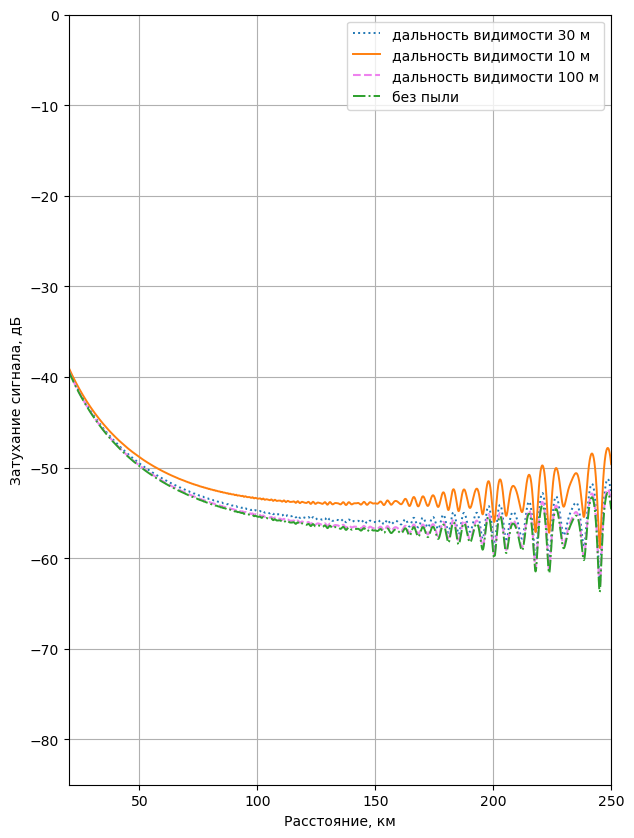

In [118]:
import array as arr 
# numbers = arr.array('d', data[:, round(350/1000/5000)])
index = 1
numbers1 = arr.array('d', path_loss[index,:])
#numbers2 = arr.array('d', data2[:,round(350/1000/1000)])
numbers3 = arr.array('d', path_loss3[index,:])
# # numbers7 = arr.array('d', data7[:, round(350/1000/4000)])
numbers4 = arr.array('d', path_loss4[index,:])
numbers5 = arr.array('d', path_loss5[index,:])
# numbers6 = arr.array('d', data6[:, round(350/1000/10)])


x = np.linspace(0,250,N_z)


 # Plotting both the curves simultaneously 
plt.figure(figsize=(7,10))
# plt.plot(numbers, y, linestyle='-',linewidth='1.4',  label='dz = 0.2 м') #0
plt.plot(x,numbers1, linestyle=':', linewidth='1.4', label='дальность видимости 30 м') 
# plt.plot(numbers2, y, linestyle='-', linewidth='1.4',color='b',  label='dz = 1 м')
plt.plot(x, numbers3, linestyle='-', linewidth='1.4',  label='дальность видимости 10 м') 
plt.plot(x, numbers4, linestyle='--', linewidth='1.5',color='violet', label='дальность видимости 100 м')
# # plt.plot(numbers7, y, linestyle=':',linewidth='1.4',  label='dz = 0.25 м') 
plt.plot(x, numbers5, linestyle='-.',linewidth='1.4',  label='без пыли') 
# plt.plot(numbers6, y, linestyle=':',linewidth='1.4',  label='dz = 100 м')

plt.xlabel('Расстояние, км')
plt.ylabel('Затухание сигнала, дБ')
plt.xlim(20,250)
plt.ylim(-85,0)
# plt.xticks(x, np.linspace(0, 250, N_z))
  
# Adding legend, which helps us recognize the curve according to it's color 
plt.legend() 
  
# To load the display window 
plt.grid() 
plt.show() 

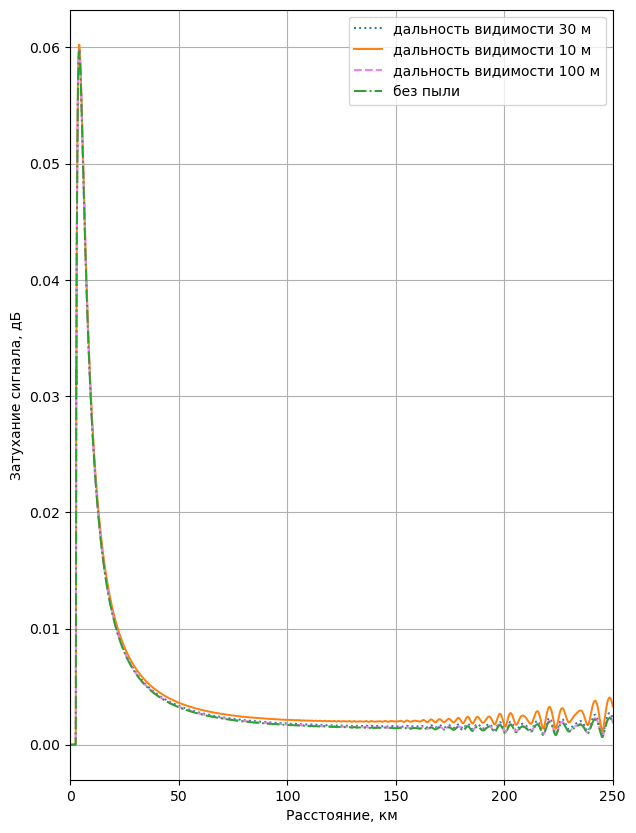

In [121]:
import array as arr 
# numbers = arr.array('d', data[:, round(350/1000/5000)])
index = 1
numbers1 = arr.array('d', data1[index,:])
#numbers2 = arr.array('d', data2[:,round(350/1000/1000)])
numbers3 = arr.array('d', data3[index,:])
# # numbers7 = arr.array('d', data7[:, round(350/1000/4000)])
numbers4 = arr.array('d', data4[index,:])
numbers5 = arr.array('d', data5[index,:])
# numbers6 = arr.array('d', data6[:, round(350/1000/10)])


x = np.linspace(0,250,N_z)


 # Plotting both the curves simultaneously 
plt.figure(figsize=(7,10))
# plt.plot(numbers, y, linestyle='-',linewidth='1.4',  label='dz = 0.2 м') #0
plt.plot(x,numbers1, linestyle=':', linewidth='1.4', label='дальность видимости 30 м') 
# plt.plot(numbers2, y, linestyle='-', linewidth='1.4',color='b',  label='dz = 1 м')
plt.plot(x, numbers3, linestyle='-', linewidth='1.4',  label='дальность видимости 10 м') 
plt.plot(x, numbers4, linestyle='--', linewidth='1.5',color='violet', label='дальность видимости 100 м')
# # plt.plot(numbers7, y, linestyle=':',linewidth='1.4',  label='dz = 0.25 м') 
plt.plot(x, numbers5, linestyle='-.',linewidth='1.4',  label='без пыли') 
# plt.plot(numbers6, y, linestyle=':',linewidth='1.4',  label='dz = 100 м')

plt.xlabel('Расстояние, км')
plt.ylabel('Затухание сигнала, дБ')
plt.xlim(0,250)

# plt.xticks(x, np.linspace(0, 250, N_z))
  
# Adding legend, which helps us recognize the curve according to it's color 
plt.legend() 
  
# To load the display window 
plt.grid() 
plt.show() 

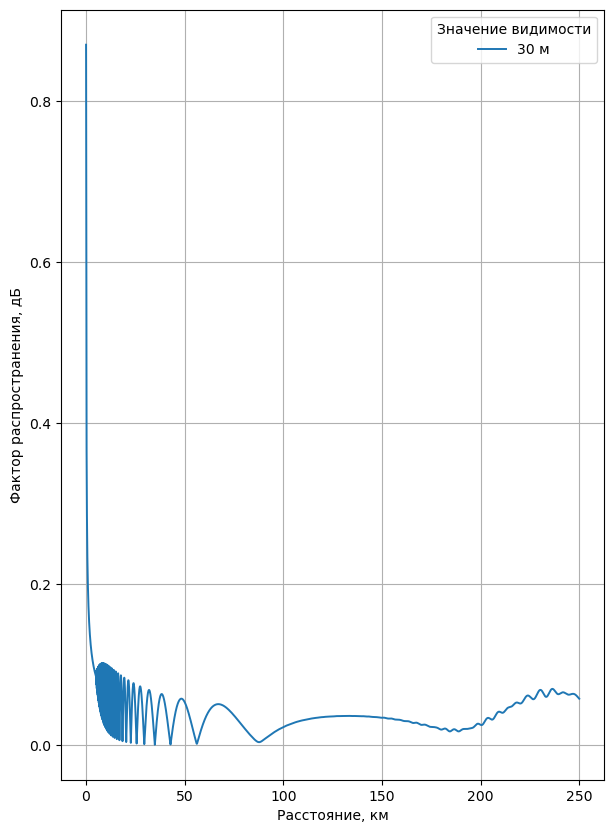

In [84]:
import array as arr 
# numbers = arr.array('d', data[:, round(350/1000/5000)])
numbers1 = arr.array('d', data1[249,0:N_z])
# numbers2 = arr.array('d', data2[:,round(350/1000/1000)])
# numbers3 = arr.array('d', data3[:, round(350/1000/500)])
# # numbers7 = arr.array('d', data7[:, round(350/1000/4000)])
# numbers4 = arr.array('d', data4[:, round(350/1000/200)])
# numbers5 = arr.array('d', data5[:, round(350/1000/50)])
# numbers6 = arr.array('d', data6[:, round(350/1000/10)])

y=np.linspace(0,height,N_x)
x = np.linspace(0,250,N_z)


 # Plotting both the curves simultaneously 
plt.figure(figsize=(7,10))
# plt.plot(numbers, y, linestyle='-',linewidth='1.4',  label='dz = 0.2 м') #0
plt.plot(x,numbers1, linestyle='-', linewidth='1.4', label='30 м') 
# plt.plot(numbers2, y, linestyle='-', linewidth='1.4',color='b',  label='dz = 1 м')
# plt.plot(numbers3, y, linestyle=':', linewidth='1.4',  label='dz = 2 м') 
# plt.plot(numbers4, y, linestyle='-', linewidth='1.5',color='black', label='dz = 5 м')
# # plt.plot(numbers7, y, linestyle=':',linewidth='1.4',  label='dz = 0.25 м') 
# plt.plot(numbers5, y, linestyle=':',linewidth='1.4',  label='dz = 20 м')
# plt.plot(numbers6, y, linestyle=':',linewidth='1.4',  label='dz = 100 м')

plt.xlabel('Расстояние, км')
plt.ylabel('Фактор распространения, дБ')
# plt.xlim(0,1)
# plt.xticks(x, np.linspace(0, 250, N_z))
  
# Adding legend, which helps us recognize the curve according to it's color 
plt.legend(title='Значение видимости') 
  
# To load the display window 
plt.grid()
plt.show() 

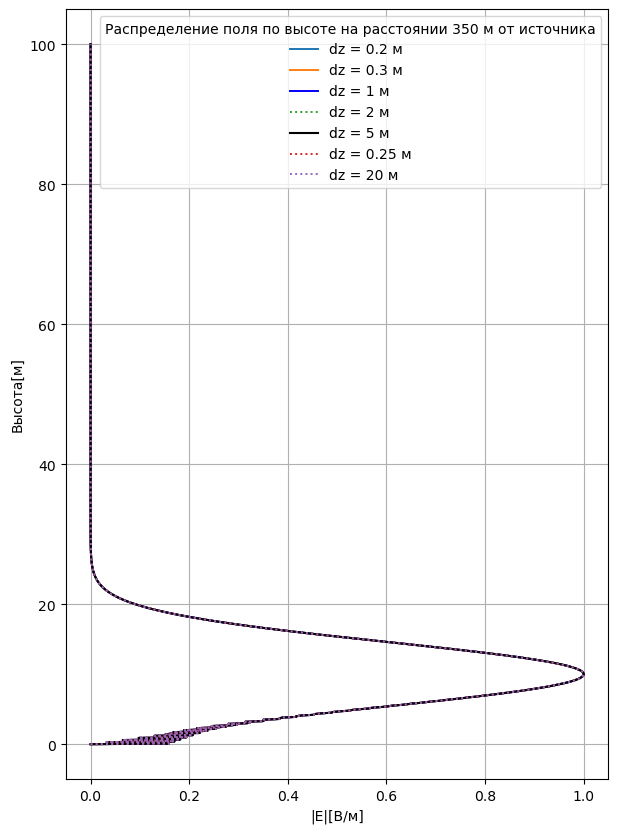

In [16]:
import array as arr 
# numbers = arr.array('d', data[:, round(350/1000/5000)])
numbers1 = arr.array('d', data1[:,round(350/1000/3000)])
numbers2 = arr.array('d', data2[:,round(350/1000/1000)])
numbers3 = arr.array('d', data3[:, round(350/1000/500)])
# numbers7 = arr.array('d', data7[:, round(350/1000/4000)])
numbers4 = arr.array('d', data4[:, round(350/1000/200)])
numbers5 = arr.array('d', data5[:, round(350/1000/50)])
# numbers6 = arr.array('d', data6[:, round(350/1000/10)])

y=np.linspace(0,height,N_x)



 # Plotting both the curves simultaneously 
plt.figure(figsize=(7,10)) 
# plt.plot(numbers, y, linestyle='-',linewidth='1.4',  label='dz = 0.2 м') #0
plt.plot(numbers1, y, linestyle='-', linewidth='1.4', label='dz = 0.3 м') 
plt.plot(numbers2, y, linestyle='-', linewidth='1.4',color='b',  label='dz = 1 м')
plt.plot(numbers3, y, linestyle=':', linewidth='1.4',  label='dz = 2 м') 
plt.plot(numbers4, y, linestyle='-', linewidth='1.5',color='black', label='dz = 5 м')
# plt.plot(numbers7, y, linestyle=':',linewidth='1.4',  label='dz = 0.25 м') 
plt.plot(numbers5, y, linestyle=':',linewidth='1.4',  label='dz = 20 м')
# plt.plot(numbers6, y, linestyle=':',linewidth='1.4',  label='dz = 100 м')

plt.xlabel('|E|[В/м]')
plt.ylabel('Высота[м]')
# plt.xlim(0,1)

  
# Adding legend, which helps us recognize the curve according to it's color 
plt.legend(title='Распределение поля по высоте на расстоянии 350 м от источника') 
  
# To load the display window 
plt.grid()
plt.show() 

In [13]:
import numpy as np
max_value = max(max(row) for row in data7)
max_value

1.000065

In [14]:
# Находим индексы максимального элемента во всем массиве
max_index = np.unravel_index(np.argmax(data7, axis=None), data7.shape)
max_index


(100, 0)

In [447]:
max(data7[:,0])

1.000065

In [15]:
data7[1,90]

0.01015723

In [450]:
points_z =len(list(zip(*data7)))
points_x =len(data7)

m=0
m1= range/4
m2 = range/2
m3 = 2*range/3
m4 = 4*range/5
m5 = range
p=m/(range/points_z)
p1=m1/(range/points_z)
p2=m2/(range/points_z)
p3=m3/(range/points_z)
p4= m4/(range/points_z) 
p5 = m5/(range/points_z) - 1
points_x

500

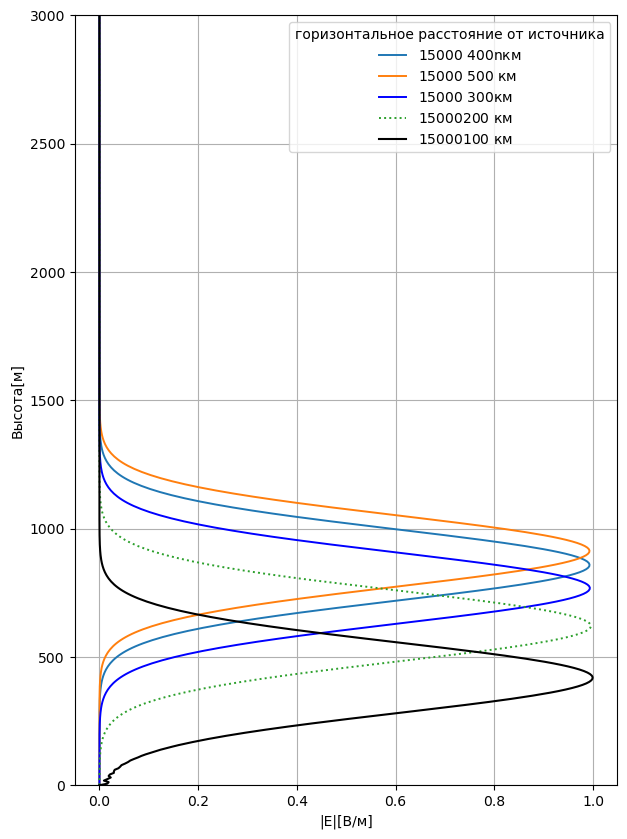

In [465]:
import array as arr 
numbers = arr.array('d', data7[:, round(p)])
numbers1 = arr.array('d', data7[:,round(p1)])
numbers2 = arr.array('d', data7[:,round(p2)])
numbers3 = arr.array('d', data7[:, round(p3)])
numbers4 = arr.array('d', data7[:, round(p4)])
numbers5 = arr.array('d', data7[:, round(p5)])

y=np.linspace(0,height,points_x)



 # Plotting both the curves simultaneously 
plt.figure(figsize=(7,10))
plt.plot(numbers, y, linestyle='-',linewidth='1.4',  label='$ {} $ км'.format(round(m))) #0
plt.plot(numbers1, y, linestyle='-', linewidth='1.4', label='$ {} $ км'.format(round(m1))) 
plt.plot(numbers2, y, linestyle='-', linewidth='1.4',color='b',  label='$ {} $ км'.format(round(m2)))
plt.plot(numbers3, y, linestyle=':', linewidth='1.4', label='$ {} $ км'.format(round(m3))) 
plt.plot(numbers4, y, linestyle='-', linewidth='1.5',color='black', label='$ {} $ км'.format(round(m4)))
plt.plot(numbers5, y, linestyle='-',linewidth='1.4',  label='$ {} $ км'.format(round(m5))) 


plt.xlabel('|E|[В/м]')
plt.ylabel('Высота[м]')
# plt.xlim(0,1)
plt.ylim(0,height)
  
# Adding legend, which helps us recognize the curve according to it's color 
plt.legend(title='горизонтальное расстояние от источника') 
  
# To load the display window 
plt.grid()
plt.show() 


In [406]:
k_0=2.0*math.pi*2.e9/3.e8
gamma_horiz = 15*math.pi/180
array_u = cmath.exp(cmath.sqrt(-1)*k_0*10*cmath.sin(gamma_horiz)) + pow(-1,1)*cmath.exp(cmath.sqrt(-1)*k_0*(-10)*cmath.sin(gamma_horiz))
abs(array_u)
array_u

1.9991636025430877j

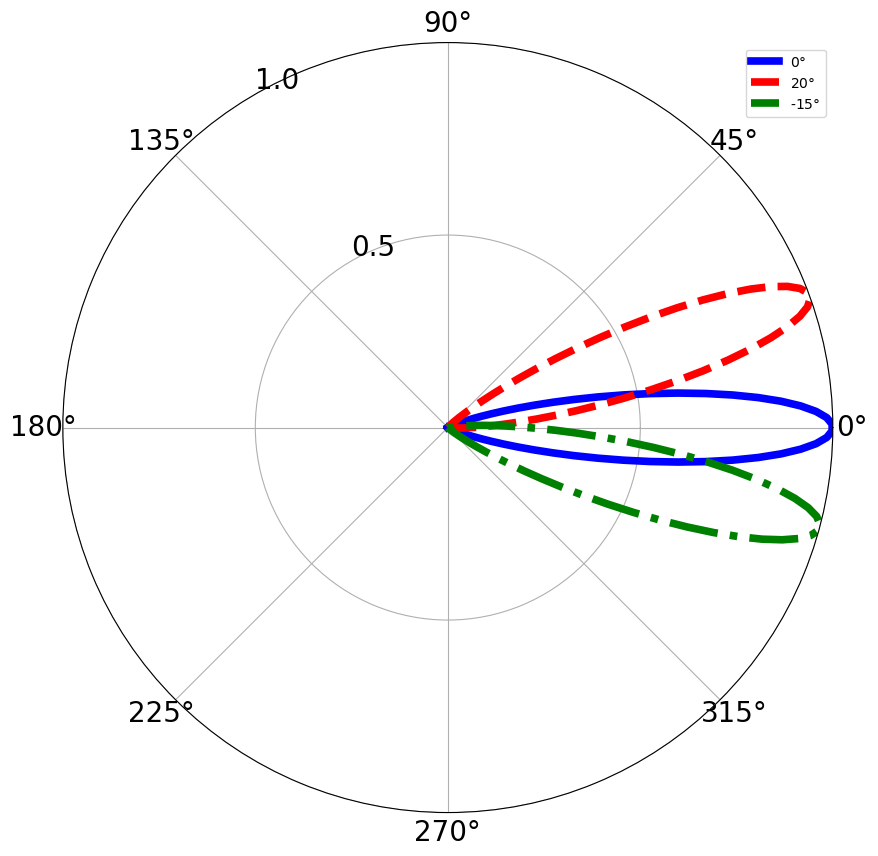

In [202]:
import numpy as np
import matplotlib.pyplot as plt

# Define the beamwidth in degrees
beamwidth_degrees = 20
beamwidth_radians = np.radians(beamwidth_degrees)

# Define the angle in radians
theta = np.radians(np.linspace(-180, 180, 360))

# Define the Gaussian pattern
def gaussian_pattern(theta, beamwidth):
    return np.exp(-4 * np.log(2) * (theta / beamwidth) ** 2)

# Generate the radiation patterns for different orientations
r1 = gaussian_pattern(theta, beamwidth_radians)
r2 = gaussian_pattern(np.abs(theta - np.pi / 9), beamwidth_radians)  # Offset by 30 degrees
r3 = gaussian_pattern(-np.abs(theta + np.pi / 12), beamwidth_radians)  # Offset by 60 degrees

# Create a polar plot
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Plot the radiation patterns
ax.plot(theta, r1, 'b-', linewidth='5.5', label='0$\degree$')
ax.plot(theta, r2, 'r--', linewidth='5.5', label='20$\degree$')
ax.plot(theta, r3, 'g-.', linewidth='5.5', label='-15$\degree$')

# Add labels
ax.set_rmax(1)
ax.set_rticks([0.5, 1])  # Less radial ticks
ax.set_rlabel_position(120)  # Move radial labels away from plotted line
plt.xticks(fontsize=20)  # Размер шрифта для делений по окружности
plt.yticks(fontsize=20)  # Размер шрифта для радиальных делений
ax.tick_params(labelsize=20)  # Общий размер цифр

ax.grid(True)

# Add a legend
ax.legend(loc='best')

# Show the plot
plt.show()

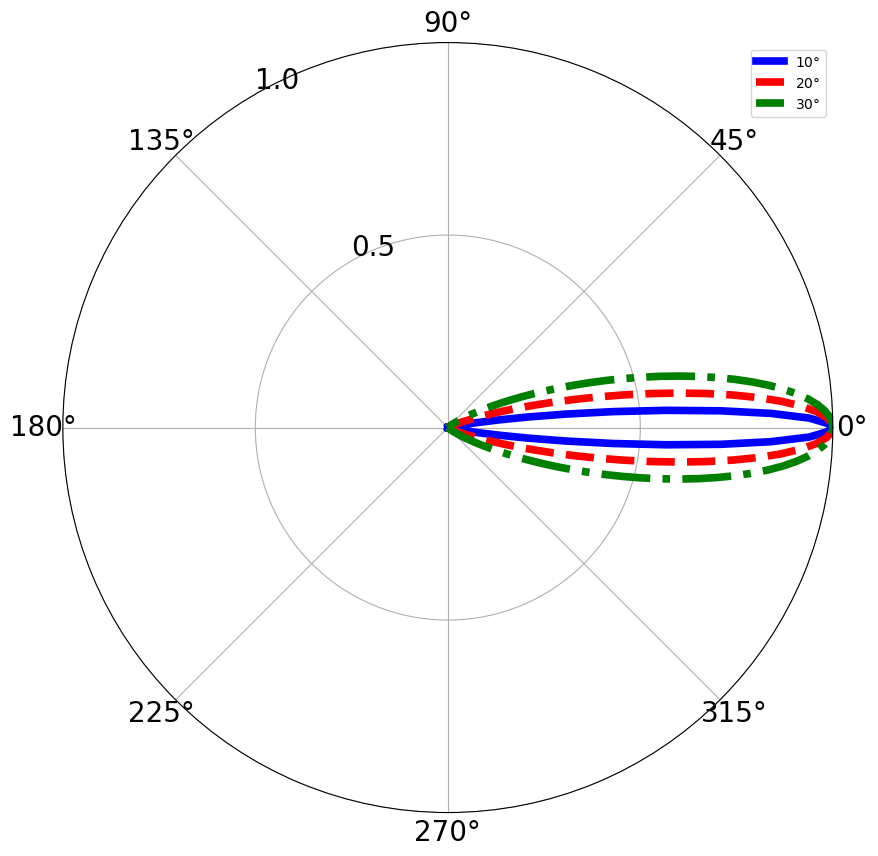

In [205]:
import numpy as np
import matplotlib.pyplot as plt

# Define the beamwidth in degrees

beamwidth_radians = [np.radians(10), np.radians(20), np.radians(30)]

# Define the angle in radians
theta = np.radians(np.linspace(-180, 180, 360))

# Define the Gaussian pattern
def gaussian_pattern(theta, beamwidth):
    return np.exp(-4 * np.log(2) * (theta / beamwidth) ** 2)

# Generate the radiation patterns for different orientations
r1 = gaussian_pattern(theta, beamwidth_radians[0])
r2 = gaussian_pattern(theta, beamwidth_radians[1])  # Offset by 30 degrees
r3 = gaussian_pattern(theta, beamwidth_radians[2])  # Offset by 60 degrees

# Create a polar plot
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Plot the radiation patterns
ax.plot(theta, r1, 'b-',linewidth='5.5', label='10$\degree$')
ax.plot(theta, r2, 'r--',linewidth='5.5', label='20$\degree$')
ax.plot(theta, r3, 'g-.', linewidth='5.5',label='30$\degree$')

# Add labels
ax.set_rmax(1)
ax.set_rticks([0.5, 1])  # Less radial ticks
ax.set_rlabel_position(120)  # Move radial labels away from plotted line
ax.grid(True)
plt.xticks(fontsize=20)  # Размер шрифта для делений по окружности
plt.yticks(fontsize=20)  # Размер шрифта для радиальных делений
ax.tick_params(labelsize=20)  # Общий размер цифр

# Add a legend
ax.legend(loc='best')

# Show the plot
plt.show()